https://data.cso.ie/table/FY008B

FY008B  Population -2011,2016,2022

## <font color='#1D76BA'>MSC_DA_CA1<font color='#00A859'>
#### <font color='#'>**Programming for DA - Statistics for Data Analytics - Machine Learning for Data Analysis & Data Preparation & Visualisation
#### <font color='#1ABC9C'>**Lecturer(s): Sam Weiss/ David Gonzalez, Bharathi Chakravarthi/ Marina Iantorno, Muhammad Iqbal and David McQuaid**
------
<font color='#E74C3C'>**Students name / ID** // Rosilene Francisca da Silva - 2021090

## Business Understanding

This is a project using Python programming language to use data to Analysis the Scenario of Population in Ireland.
It is an extensive project that covers some data analysis topics, which combines statistical analysis, programming, data preparation, visualisation, and machine learning approaches. Each of these aspects is critical in translating raw data into usable insights. The foundation for comprehending the data's inherent patterns and correlations will be provided by statistical analysis. For efficient data processing and analysis, programming abilities, notably in Python, for effective data manipulation and analysis, a language suitable for data analytics is used. Critical thinking was exercised, and each step was meticulously explained. The Python code was implemented in a Jupyter Notebook, has adequate documentation and all decisions were supported by concise explanations and arguments.

Census count of population to be evaluated by age and sex;

## Data Understanding & Data Preparation

### Exploratory Data Analysis (EDA), Data Cleaning and Statistics 

The dataset was researched on the Central Statistics Office Ireland website: https://data.cso.ie/table/FY008B that CSV file was downloaded onto Python.

/ Python Tool and Library Implementation
/ Exploratory Data Analysis (EDA)
/ Statistics 
/ Observing and describing the dataset

#### Importing the required libraries:

The first thing I will have to do is import the necessary packages to get started.

In [140]:
#Importing the essential libraries, which are Pandas, Matplotlib, Seaborn, and Numpy.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
from matplotlib import cm

%matplotlib inline

#Warnings: It can handle alert and warning messages with a number of commands and functions.
import warnings
warnings.filterwarnings('ignore')

In [141]:
#Command to display all columns in the file.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

It is time to read the file/dataset now that the libraries have been imported. The file is in '.csv' format, which is a cost-effective way to store data in tables. The pandas library contains a function called `.read_csv()` that can read this sort of file and transform it into a DataFrame. So let's read the dataset and then visualise it using the df.head() function.

In [142]:
# Importing the Dataset 
datapop_df = pd.read_csv("irelandpopulation.csv")

Let's have a look at the information in our Datasets regarding the features it is a quickly preview the data and gain a basic understanding of its structure. Displaying the first five rows of the dataset by default.

In [143]:
datapop_df.head()

,Statistic Label,CensusYear,Detailed Marital Status,County and City,Sex,Age Group,UNIT,VALUE
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
1,Population,2011,All marital status,State,Both sexes,Under 25 years,Number,1559840
2,Population,2011,All marital status,State,Both sexes,25 - 29 years,Number,361122
3,Population,2011,All marital status,State,Both sexes,30 - 34 years,Number,393945
4,Population,2011,All marital status,State,Both sexes,35 - 39 years,Number,364261


Displaying the last rows of the dataset. By default, it returns the last five rows if `n` is not specified.
The target variable is 'UnitValue'.

In [144]:
datapop_df.tail()

,Statistic Label,CensusYear,Detailed Marital Status,County and City,Sex,Age Group,UNIT,VALUE
33475,Population,2022,Widowed,Monaghan,Female,65 - 69 years,Number,201
33476,Population,2022,Widowed,Monaghan,Female,70 - 74 years,Number,332
33477,Population,2022,Widowed,Monaghan,Female,75 - 79 years,Number,359
33478,Population,2022,Widowed,Monaghan,Female,80 - 84 years,Number,363
33479,Population,2022,Widowed,Monaghan,Female,85 years and over,Number,522


In [145]:
 # Display the dimensions of the Dataset
datapop_df.shape

(33480, 8)

The data sets contain 33,480 observation/rows and 8 attributes.

In [146]:
#Analyse the data collection period 
import datetime
start = pd.to_datetime(datapop_df['CensusYear']).dt.date.min()
end = pd.to_datetime(datapop_df['CensusYear']).dt.date.max()
print('Data period - From:', start, 'to:', end)

Data period - From: 1970-01-01 to: 1970-01-01


The `df.info()` method is crucial because it examines each column of the DataFrame, revealing the total number of entries, datatypes, and quantity of null data. It also provides some extremely helpful observations.

In [147]:
datapop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33480 entries, 0 to 33479
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Statistic Label          33480 non-null  object
 1   CensusYear               33480 non-null  int64 
 2   Detailed Marital Status  33480 non-null  object
 3   County and City          33480 non-null  object
 4   Sex                      33480 non-null  object
 5   Age Group                33480 non-null  object
 6   UNIT                     33480 non-null  object
 7   VALUE                    33480 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 2.0+ MB


As we can see from the information, this dataset has categorical and numerical variables, so we can state that the data types in the dataset include integers (int64) and objects (strings). We already know where to go with the analysis. For example, notice that most columns are stored as ‘object’. We also can observe that there are no null values present, but I will validate this using a special method.

We also can check the datatypes by `.dtypes` method.

In [148]:
datapop_df.dtypes

Statistic Label            object
CensusYear                  int64
Detailed Marital Status    object
County and City            object
Sex                        object
Age Group                  object
UNIT                       object
VALUE                       int64
dtype: object

The unique value indicates how many different values are in each column, and the frequency indicates how often the most prevalent value appears in each column.
Gaining an understanding of these features of the dataset will help to analyse and interpret the data more effectively by helping you understand the distribution and properties of the data within each feature.

In [149]:
datapop_df.nunique()

Statistic Label               1
CensusYear                    3
Detailed Marital Status       8
County and City              31
Sex                           3
Age Group                    15
UNIT                          1
VALUE                      7835
dtype: int64

In [150]:
#Counting the unique values of Census in the Dataset
datapop_df.select_dtypes(include='number').nunique()  

CensusYear       3
VALUE         7835
dtype: int64

We may check for null values in the datasets in a variety of ways; I chose these to determine whether there are any missing values in the datasets.

In [151]:
datapop_df.isnull().sum()

Statistic Label            0
CensusYear                 0
Detailed Marital Status    0
County and City            0
Sex                        0
Age Group                  0
UNIT                       0
VALUE                      0
dtype: int64

In [152]:
popnull = datapop_df.isna().sum().sum()
print ('Null values in datapop: {}'.format(popnull))

Null values in datapop: 0


In [153]:
datapop_df.isnull().values.any()

False

The dataset does not contain any null values. As a result, there is no need to perform it.

#### Selecting columns and rows from dataset

In [154]:
selected_column = datapop_df['Detailed Marital Status']
selected_column.head()

0    All marital status
1    All marital status
2    All marital status
3    All marital status
4    All marital status
Name: Detailed Marital Status, dtype: object

#### Selecting rows and columns
Let's display the row 1 and the last one in index from a selected columns.

In [155]:
selected_data2 = datapop_df.loc[[1, 33479], ['Detailed Marital Status', 'VALUE']]
print(selected_data2)

      Detailed Marital Status    VALUE
1          All marital status  1559840
33479                 Widowed      522


#### Selecting rows from 'Age Group' and disply the population number

In [156]:
selected_data3 = datapop_df.loc[datapop_df['Age Group'].isin(['85 years and over']),
                               ['Age Group', 'VALUE']]
selected_data3.head()

,Age Group,VALUE
14,85 years and over,58416
29,85 years and over,18486
44,85 years and over,39930
59,85 years and over,646
74,85 years and over,222


#### My next step will be to pick particular rows and columns, after which I will compute the population total for just those rows. Print this value after that.

In [157]:
value_sum = selected_data3['VALUE'].sum()
print(f"Sum of Population for 85 years and over: {value_sum}")

Sum of Population for 85 years and over: 1683296


#### Check for any duplicates

While cleaning, data duplicates are something we should be mindful of. In a nutshell, duplicates are the lines in our dataframe that have been copied, meaning that every feature has two lines with the exact same value. Since this is essentially the same observation that has been made over and over, it indicates that this data adds nothing to our model.

* The first instance of the duplicate row is to be tagged as False (meaning it isn't a duplicate), and all further occurrences are to be marked as True (meaning they are duplicates) according to the parameter `keep='first'`.

Duplicate data should be eliminated from the dataframe as soon as possible because it can interfere with our analysis and all the steps that depend on it. 

In [158]:
duplicate = datapop_df[datapop_df.duplicated(keep='first')]
print(duplicate)

Empty DataFrame
Columns: [Statistic Label, CensusYear, Detailed Marital Status, County and City, Sex, Age Group, UNIT, VALUE]
Index: []


This shows that the Dataset contains no duplicate rows. 

#### Renaming some columns with the 'rename' methods because it's more appropriate.

In [159]:
datapop_df.rename(columns={'Detailed Marital Status': 'MaritalStatus', 'County and City': 'Area', 
                           'Sex': 'Gender','Age Group': 'AgeGroup', 'VALUE': 'UnitValue' }, inplace = True)
datapop_df.head(2)

,Statistic Label,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UNIT,UnitValue
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
1,Population,2011,All marital status,State,Both sexes,Under 25 years,Number,1559840


In [160]:
datapop_df.shape

(33480, 8)

#### Some variable names contain data entry symbols and characters, and others may necessitate data type translation. I'm going to correct this error in the data.

In this case, the marital status 'Re-married,' 'Married (first marriage),' and 'Registered same-sex civil partnership' appear to be unclear. This must be corrected.

In [161]:
print(datapop_df.MaritalStatus.unique())

['All marital status' 'Single' 'Registered same-sex civil partnership'
 'Married (first marriage)' 'Re-married' 'Separated' 'Divorced' 'Widowed']


#### Adjusting the values in the searchfor list to allow to search for different patterns or strings within the 'MaritalStatus' column.

In [162]:
datapop_df['MaritalStatus'].replace({'Re-married': 'Remarried', 'Registered same-sex civil partnership': 'Registered Same Sex',
                                     'Married (first marriage)':'Married'}, inplace=True)
print(datapop_df.MaritalStatus.nunique())

8


In [163]:
#Distribution of values or categorical variables
datapop_df['MaritalStatus'].value_counts()

All marital status     4185
Single                 4185
Registered Same Sex    4185
Married                4185
Remarried              4185
Separated              4185
Divorced               4185
Widowed                4185
Name: MaritalStatus, dtype: int64

In [164]:
print(datapop_df.Area.unique())

['State' 'Carlow' 'Dublin City' 'Dún Laoghaire-Rathdown' 'Fingal'
 'South Dublin' 'Kildare' 'Kilkenny' 'Laois' 'Longford' 'Louth' 'Meath'
 'Offaly' 'Westmeath' 'Wexford' 'Wicklow' 'Clare'
 'Cork City and Cork County' 'Kerry' 'Limerick City and County'
 'Tipperary' 'Waterford City and County' 'Galway City' 'Galway County'
 'Leitrim' 'Mayo' 'Roscommon' 'Sligo' 'Cavan' 'Donegal' 'Monaghan']


In [165]:
datapop_df['Area'].replace({'Dún Laoghaire-Rathdown': 'Dun Laoghaire', 'Cork City and Cork County': 'Cork',
                                     'Limerick City and County':'Limerick','Waterford City and County':'Waterford'}, inplace=True)
print(datapop_df.Area.nunique())

31


In [166]:
print(datapop_df.Area.unique())

['State' 'Carlow' 'Dublin City' 'Dun Laoghaire' 'Fingal' 'South Dublin'
 'Kildare' 'Kilkenny' 'Laois' 'Longford' 'Louth' 'Meath' 'Offaly'
 'Westmeath' 'Wexford' 'Wicklow' 'Clare' 'Cork' 'Kerry' 'Limerick'
 'Tipperary' 'Waterford' 'Galway City' 'Galway County' 'Leitrim' 'Mayo'
 'Roscommon' 'Sligo' 'Cavan' 'Donegal' 'Monaghan']


### Descriptive Statistics

I will also reorder our df in this case based on the population's greatest number, so that perhaps we can see some errors more clearly..This is accomplished by using the `.sort_values` function, which takes three parameters to operate on: first, the column to be sorted; second, ascending, which specifies whether the values should be sorted from smallest to largest or vice versa. In this instance, I set it to `False` so that modifications made to this function affect the original dataframe rather than merely a copy, and third, I set inplace to `True`inplace set to True, so that changes made in this function are applied to the original dataframe and not just a copy. See how this plays out.

In [167]:
datapop_df.sort_values('UnitValue', ascending=False, inplace=True)
datapop_df.head()

,Statistic Label,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UNIT,UnitValue
22320,Population,2022,All marital status,State,Both sexes,All ages,Number,5149139
11160,Population,2016,All marital status,State,Both sexes,All ages,Number,4761865
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
23715,Population,2022,Single,State,Both sexes,All ages,Number,2773334
22350,Population,2022,All marital status,State,Female,All ages,Number,2604590


We can initially see that the highest values is likely to be the sum of all MaritalStatus, County/City, Sex and Age Group of the populations referring to the 2011, 2016 and 2022 Census. I will analyze this further later.

In [168]:
#provides basic statistics
datapop_df.describe()

,CensusYear,UnitValue
count,33480.000000,3.348000e+04
mean,2016.333333,6.929155e+03
std,4.496980,7.477497e+04
min,2011.000000,0.000000e+00
25%,2011.000000,2.600000e+01
50%,2016.000000,2.340000e+02
75%,2022.000000,1.720000e+03
max,2022.000000,5.149139e+06


The `.describe()` function is excellent for providing more information about numerical data such as count, quartile values, mean, standard deviation, maximum and minimum. All of this information can be used to identify unusual patterns in the dataframe. In this scenario, columns with values represented as 0 may need to be rectified, and describe assists us with this process.

In [169]:
# Getting summary statistics
datapop_df.describe().transpose().style.background_gradient(cmap= 'Blues')

,count,mean,std,min,25%,50%,75%,max
CensusYear,33480.000000,2016.333333,4.496980,2011.000000,2011.000000,2016.000000,2022.000000,2022.000000
UnitValue,33480.000000,6929.154600,74774.974254,0.000000,26.000000,234.000000,1720.000000,5149139.000000


#### Another way to evaluate a specific variable and display the information. In this case I chose the target variable 'UnitValue'.

In [170]:
print('Minimum Value: ', datapop_df['UnitValue'].min())
print('Maximum Value: ', datapop_df['UnitValue'].max())
print('Average Value:' , datapop_df['UnitValue'].mean())
print('Median Value:', datapop_df['UnitValue'].median())
print('Variance Value:', datapop_df['UnitValue'].var())
print('Mode Value:', datapop_df['UnitValue'].mode())

Minimum Value:  0
Maximum Value:  5149139
Average Value: 6929.154599761051
Median Value: 234.0
Variance Value: 5591296774.709718
Mode Value: 0    0
Name: UnitValue, dtype: int64


Some findings from the statistical analysis;

-  The 'VALUE' column's that represents the population number the standard deviation is quite high approximately '74,774.97', suggesting a notable degree of variability or dispersion in the numbers. This shows that the 'VALUE' data points are dispersed across a large range of values, which could imply a wide range of population or census data over time. 

-  A minimum value of 0 in the 'VALUE' column could indicate missing data or entries where the value was not recorded or was purposefully left blank. Examining the entries with 0 values may reveal information about possible inconsistencies and the quality of the data.

-  For the 'VALUE' column, the mean '6,929.155' is much greater than the median '234.0000'.This implies that the distribution in the 'VALUE' column may be skewed towards higher values or there may be a few extreme outliers . To find out more about the skewness, it would be helpful to look into the distribution of the 'VALUE' column.

The fact that this method can accept the datatype as a parameter with the `include` specification and might contain more precise information if, for example, we are working with categories is a crucial discovery.

Let's  see more information through the statistical values below, selecting the object type columns.

In [171]:
datapop_df.describe(include=object)

,Statistic Label,MaritalStatus,Area,Gender,AgeGroup,UNIT
count,33480,33480,33480,33480,33480,33480
unique,1,8,31,3,15,1
top,Population,All marital status,State,Both sexes,All ages,Number
freq,33480,4185,1080,11160,2232,33480


The describe method gave a summary statistics for the columns containing object data types by specifying include=object we can get some insights.
- From the index count, which shows how many values in each object column are not null. Since there are 33,480 non-null values in each of the dataframe's columns and 33,480 total records, we can infer that the dataset contains non-null values.
- From the top index, which shows the value that appears most frequently in each column. For example, 'Population' is the most common value in the MaritalStatus column. 'All marital status' is the most frequently occurring value in the Area column, and so on.
- The most common value's frequency is indicated by the 'freq'. It indicates how frequently the most common value occurs in each column in this particular scenario. For instance, 'Population' appears 33,480 times and in the MaritalStatus column, 'All marital status' appears 4,185 times, and so on.

##### In descriptive statistics, skewness is a frequently used metric that describes how asymmetrical a data distribution is. It indicates the degree of symmetry in the data distribution around the mean. It is also a highly useful statistic to help determine the appearance or shape of the data distribution when combined with kurtosis.

In [172]:
skewness = datapop_df['UnitValue'].skew()
print('Skewness is', skewness)

Skewness is 38.81706592209603


The target variable 'UnitValue' has a high skewness, in this case, a positive skewness, indicating an asymmetric tail spreading towards higher positive values. When the skewness is high, it indicates a very highly skewed distribution with a large number of outliers or a very long tail on the positive side.

##### Kurtosis is a metric used to express how far a distribution's tails deviate from a normal distribution's tails. Let's see the following formula to determine the sample kurtosis.

In [173]:
kurtosis = datapop_df['UnitValue'].kurtosis()
print('Kurtosis value is', kurtosis)

Kurtosis value is 1990.9066682378382


The kurtosis value of the variable 'Unitvalue' is extremely high. Perhaps I'll need to employ statistical procedures appropriate for such distributions, possibly after undergoing some type of transformation or employing statistical approaches.

##### I apply this function to determine a column of the dataset and count it according to its categories, in the case below the number by Area. Using the sort_values method, we can arrange area values in ascending order based on the 'UnitValue' column.

In [174]:
value_counties = datapop_df.groupby('Area')[['UnitValue']].sum() 
print(value_counties.sort_values(by = ['UnitValue']))

               UnitValue
Area                    
Leitrim           792328
Longford         1012992
Carlow           1388096
Monaghan         1497256
Roscommon        1590944
Sligo            1609008
Cavan            1848504
Offaly           1902384
Galway City      1908888
Laois            2057064
Westmeath        2169240
Kilkenny         2390488
Waterford        2858672
Clare            2911608
Louth            3131872
Mayo             3192920
Wicklow          3479328
Kerry            3597336
Wexford          3671688
Tipperary        3889616
Donegal          3899304
Galway County    4382696
Limerick         4769952
Meath            4800040
Dun Laoghaire    5265112
Kildare          5444720
South Dublin     6760376
Fingal           7204136
Cork            13168448
Dublin City     13399032
State          115994048


In [175]:
count = (datapop_df['Area'] == 'Dublin City').sum()
count

1080

It's display the frequency that 'Dublin City' value apear on the dataset.

In [176]:
#Distribution of values or categorical variables
datapop_df['Gender'].value_counts()

Both sexes    11160
Female        11160
Male          11160
Name: Gender, dtype: int64

#### Let's observe the above information all at once through graphs

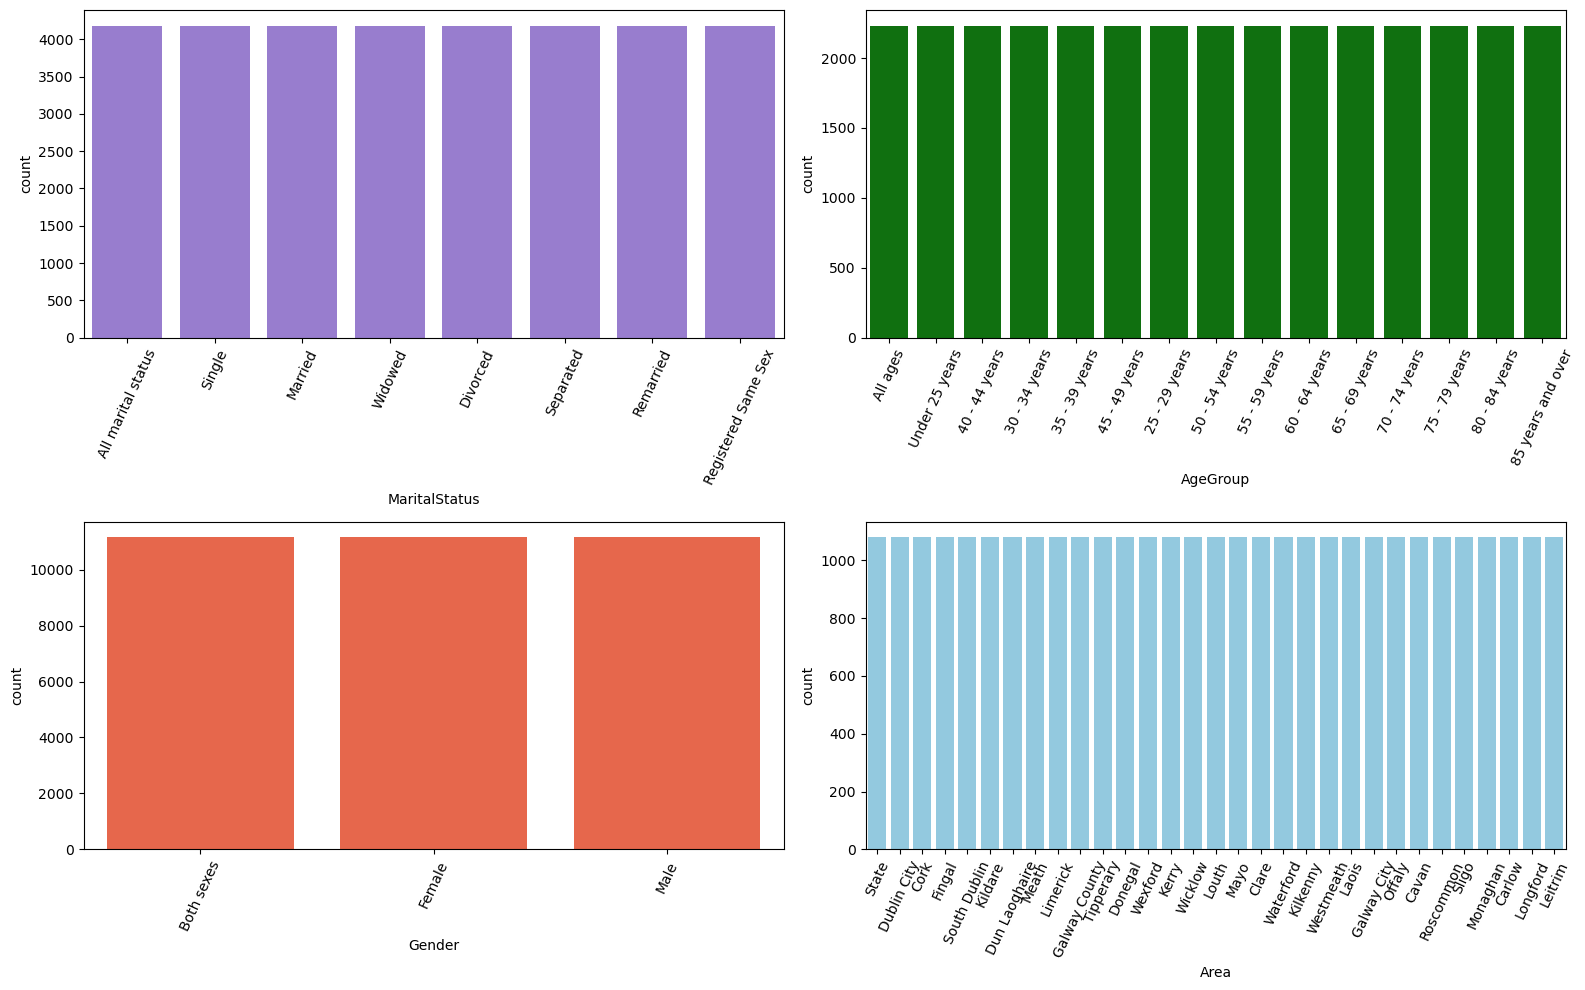

In [177]:
f, axes = plt.subplots(2, 2)
plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['figure.autolayout'] = True
sns.countplot(data = datapop_df, x='MaritalStatus', ax=axes[0][0],color='mediumpurple')
sns.countplot(data = datapop_df, x='AgeGroup', ax=axes[0][1], color='green')
sns.countplot(data = datapop_df, x='Gender', ax=axes[1][0], color='#FF5733')
sns.countplot(data = datapop_df, x='Area', ax=axes[1][1], color='skyblue')
for ax in f.axes:
    plt.sca(ax)
    plt.xticks(rotation=65)
plt.show()

We can see a uniform distribution throughout these graphs, indicating a uniform distribution between the categories.

For further analysis it will be important to consider the context of this data. Is there a reason to expect an equal distribution between these categories? This is an important analysis to be made and questioned further.

#### Using scatter to display the population distribution in the Area and Age Group columns.

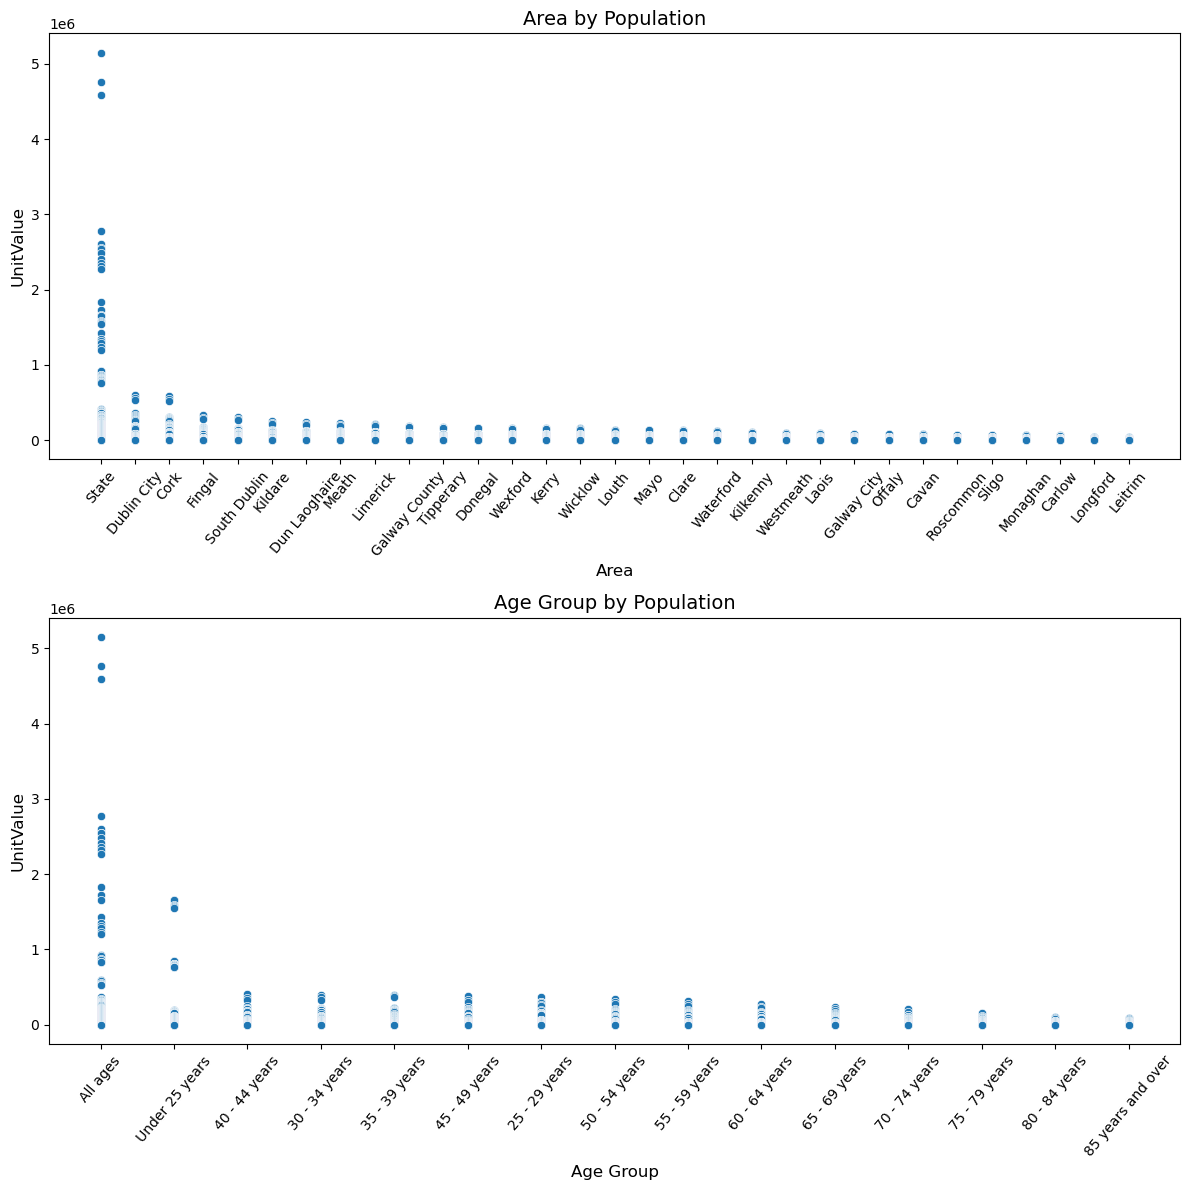

In [178]:
fig, axs = plt.subplots(2, 1, figsize=(12, 12))
sns.scatterplot(x='Area', y='UnitValue', data=datapop_df, ax=axs[0])
axs[0].set_title('Area by Population', fontsize=14)   
axs[0].set_xlabel('Area', fontsize=12)  
axs[0].set_ylabel('UnitValue', fontsize=12)
sns.scatterplot(x='AgeGroup', y='UnitValue', data=datapop_df, ax=axs[1])
axs[1].set_title('Age Group by Population', fontsize=14)   
axs[1].set_xlabel('Age Group', fontsize=12)  
axs[1].set_ylabel('UnitValue', fontsize=12) 
for ax in axs:
    ax.tick_params(axis='x', labelsize=10, rotation=50)  
    ax.tick_params(axis='y', labelsize=10) 
plt.tight_layout()
plt.show()

Based on this visualisation, we can see that the population number in the observations 'Satate' from Area and 'All Ages' from Age Group is significantly higher than the population number in the other observations. We may use this to see if these variables add up to the total values of the others in each selected column.

** To see the distribution of the population data for various years or marital statuses, use a box plot. This will help you see any anomalies or changes in the data.

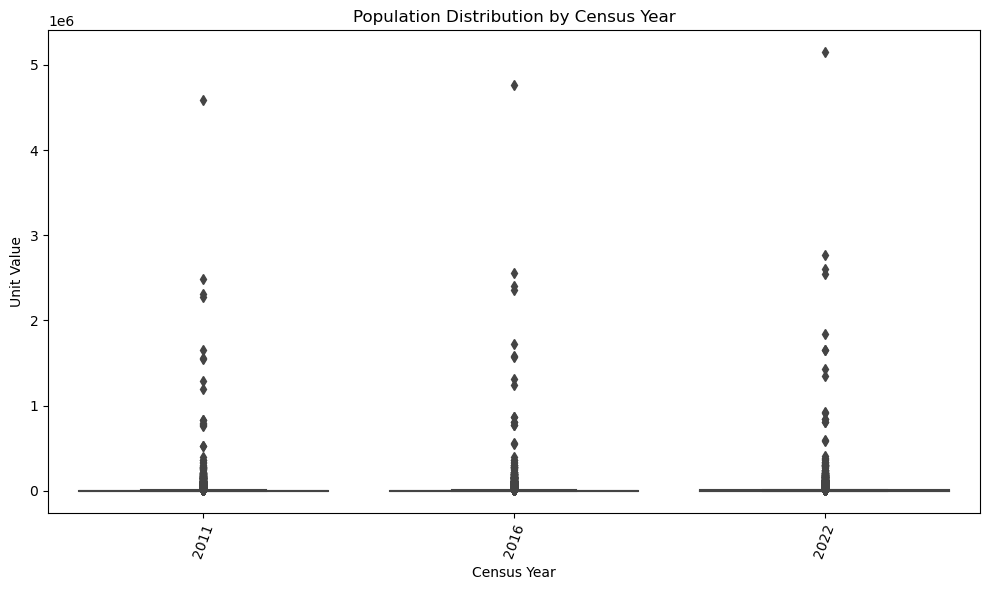

In [165]:
#BOX PLOT
plt.figure(figsize=(10,6))
plt.xticks(rotation=70)
sns.boxplot(x='CensusYear', y='UnitValue', data=datapop_df, palette = 'husl');
plt.title('Population Distribution by Census Year')
plt.xlabel('Census Year')
plt.ylabel('Unit Value')
plt.show()

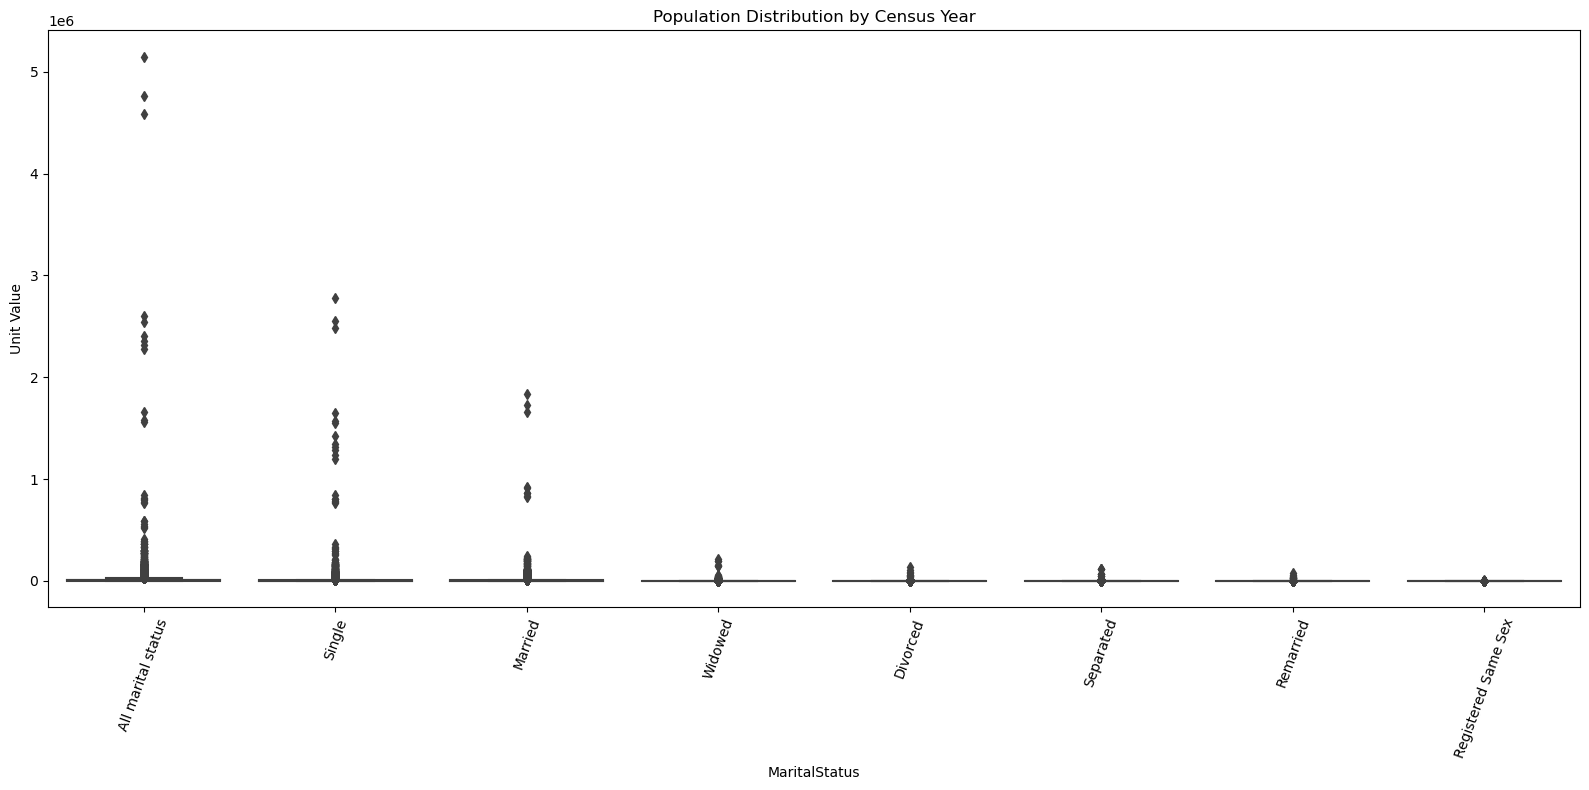

In [166]:
#BOX PLOT
plt.figure(figsize=(16,8))
plt.xticks(rotation=70)
sns.boxplot(x='MaritalStatus', y='UnitValue', data=datapop_df, palette = 'husl');
plt.title('Population Distribution by Census Year')
plt.xlabel('MaritalStatus')
plt.ylabel('Unit Value')
plt.show()

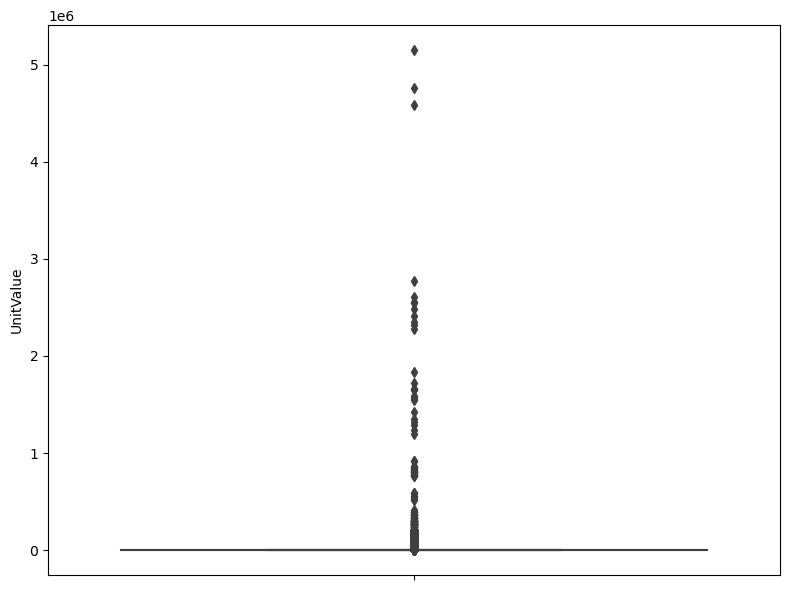

In [167]:
plt.figure(figsize=(8,6))
plt.xticks(rotation=70)
sns.boxplot(data = datapop_df, y = 'UnitValue')
plt.show()

##### Histogram
Using the histogram to displays the shape and distribution of the UnitValue of data. Understanding a dataset's distribution and form, as well as spotting any outliers or odd trends, can be accomplished with its help. 

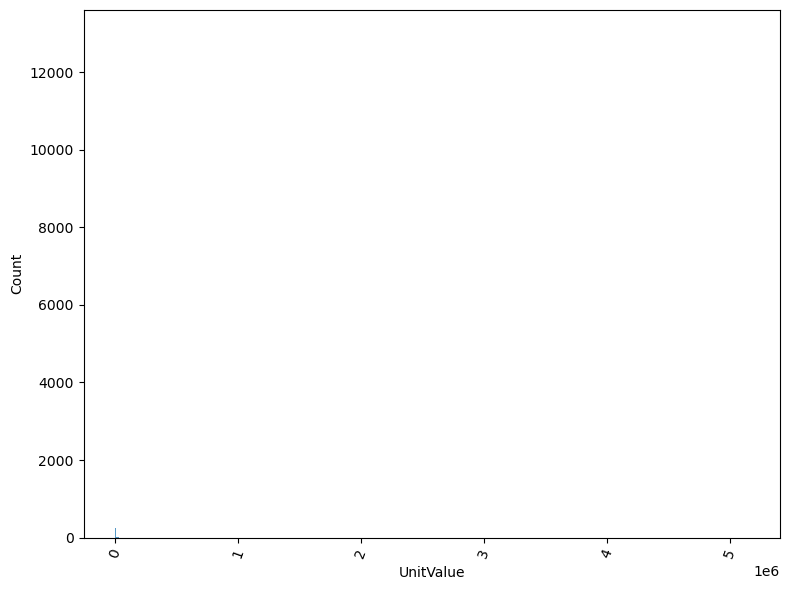

In [171]:
plt.figure(figsize=(8,6))
plt.xticks(rotation=70)
sns.histplot(datapop_df['UnitValue'])
plt.show()

#### Normal distribution

Displaying the visualization of a normal distribution:

Let's shows two subplots in a matplotlib, each with a separate y-axis.
The box plot used to show the normal distribution data is the first subplot.

A histogram showing the normal distribution's density is the second subplot. It appends a red dashed line to the distribution's median. Four green dotted lines are added at each quartile's location.

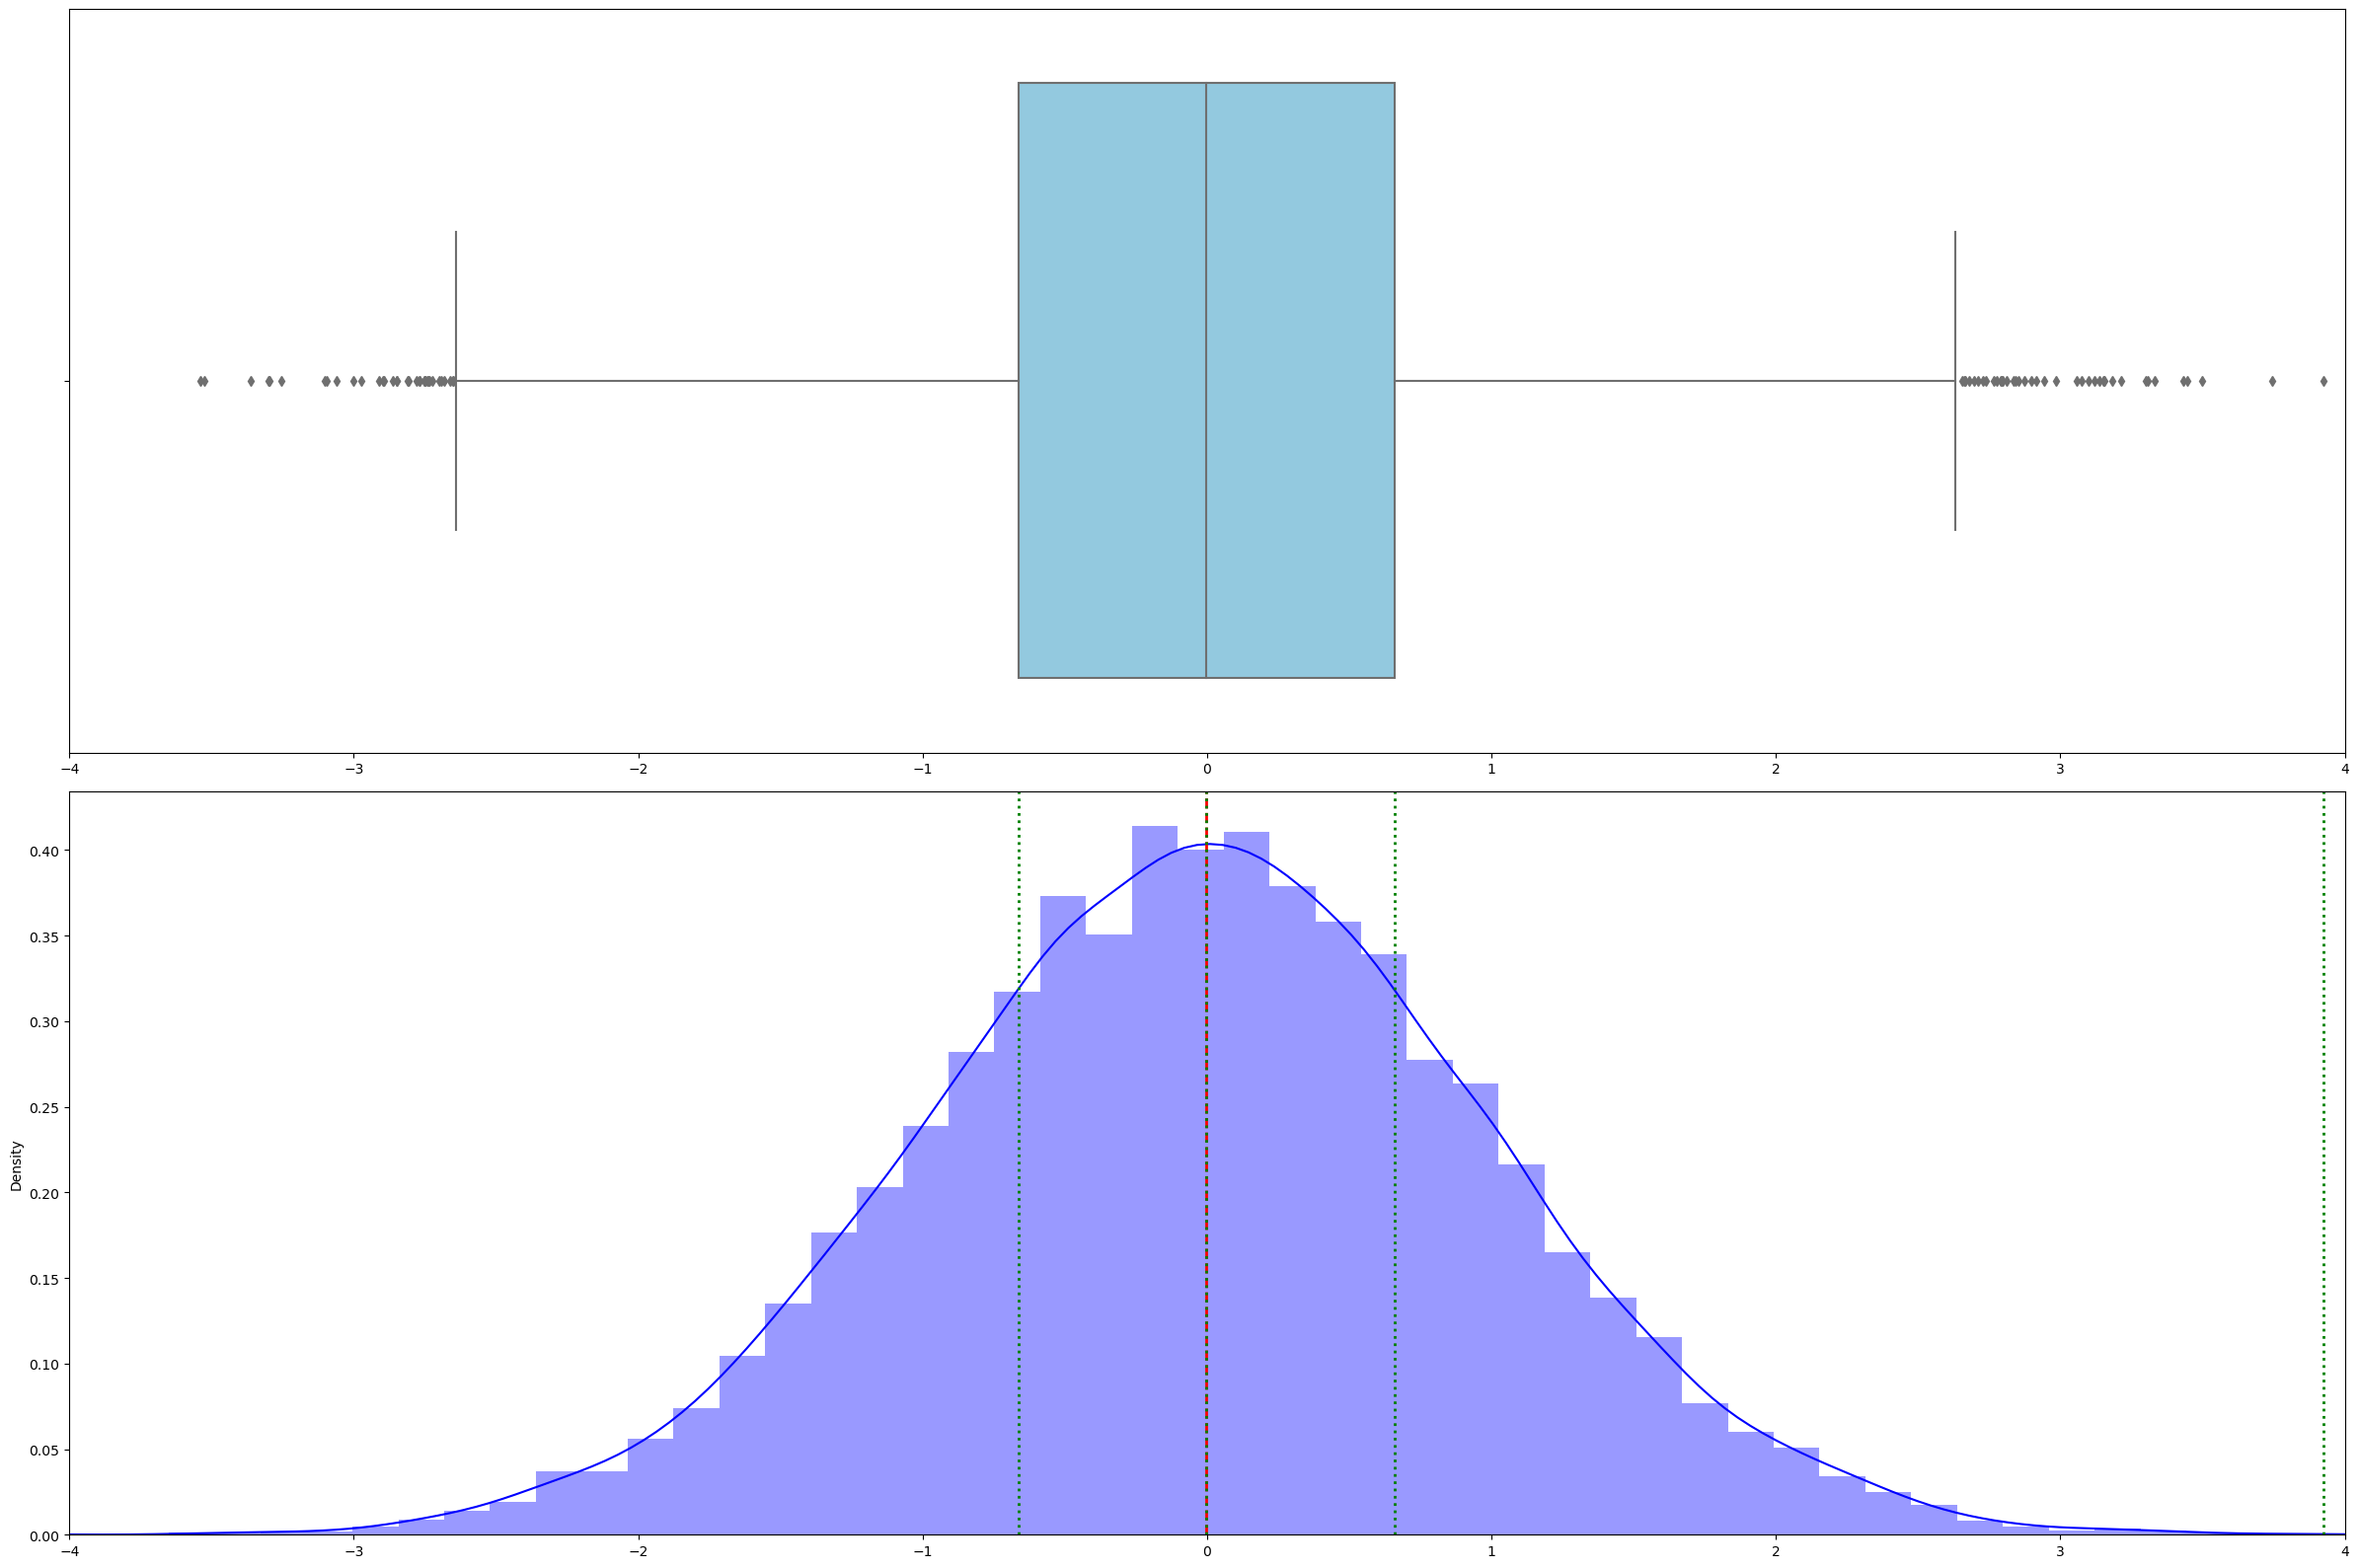

In [172]:
normal = np.random.normal(0, 1, 10000)
quartiles = pd.DataFrame(normal).quantile([0.25, 0.5, 0.75, 1])[0]
fig, axs = plt.subplots(nrows=2, figsize=(24, 16))

# Normal distribution - Boxplot
plot1 = sns.boxplot(x=normal, ax=axs[0], color='skyblue').set(xlim=(-4, 4))

# Normal distribution - Histogram 
plot2 = sns.distplot(normal, ax=axs[1], color='blue').set(xlim=(-4, 4))

# Median line
plt.axvline(np.median(normal), color='r', linestyle='dashed', linewidth=2)
for i, q in enumerate(quartiles):
    
# Quartile i line
    plt.axvline(q, color='g', linestyle='dotted', linewidth=2)
plt.show()

I chose these plots because they provide a thorough visual representation of the features of a normal distribution, with markers for the median and quartiles, a box plot, and a histogram.

Outliers can negatively bias the entire result of an analysis;

### Dropping some of Columns and observations (rows)
We already have an overview of the dataset, and it is evident from my analysis that some of observations and columns will not be relevant. Since this won't have an impact on the data's quality, I will remove certain columns to create a more consistent analysis.

#### Dropping the columns 'Statistic Label' and 'UNIT'.

For example; The 'Statistic Label' column represents the label/name of the statistic being recorded or measured.
The 'UNIT' column represent the unit of measurement for the 'Value' column. In this case it is a'Number', indicating that the value reflects a count or a numerical quantity.

In [177]:
datapop_df.drop(columns=['Statistic Label','UNIT'],inplace=True, axis=1)
datapop_df.head(2)

KeyError: "['Statistic Label', 'UNIT'] not found in axis"

I used `inplace=True`, `axis=1`, and the drop method to explicitly tell pandas to delete the desired columns from the DataFrame without establishing a new DataFrame.

#### Dropping some of observations (rows) 

I considered removing a few rows (observations) from the dataset. Naturally, evaluating the data's quality, applicability to the goals of the study, and effect of outliers on the analysis as a whole must come first. Before dropping any observations, I carefully considered the influence on the total dataset and ensured that the remaining data is representative and appropriate for  for addressing the research questions.

In this case, I noticed that some rows are not relevant in this analysis , such as: 'All marital status', 'Both sexes', 'All ages' and 'State', as they only add up to the overall sum of data that we already have in other observations and high outliers are the outcome of this. Dropping them can help streamline the analysis and concentrate on the most important data points.

In [ ]:
datapop_df.drop(datapop_df[datapop_df['MaritalStatus'] == 'All marital status'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['Gender'] == 'Both sexes'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['AgeGroup'] == 'All ages'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['Area'] == 'State'].index, inplace=True)
datapop_df.head(2)

In [41]:
datapop_df.shape

(17640, 8)

dict_Gender = {'Male':1, 'Female': 2,}
datapop_df['Gender'] = datapop_df['Gender'].map(dict_Gender)

datapop_df['Gender'].replace(dict_Gender, inplace=True)
datapop_df.head(5)

[Text(0.5, 0, 'Uniform _Distribution'), Text(0, 0.5, 'Frequency')]

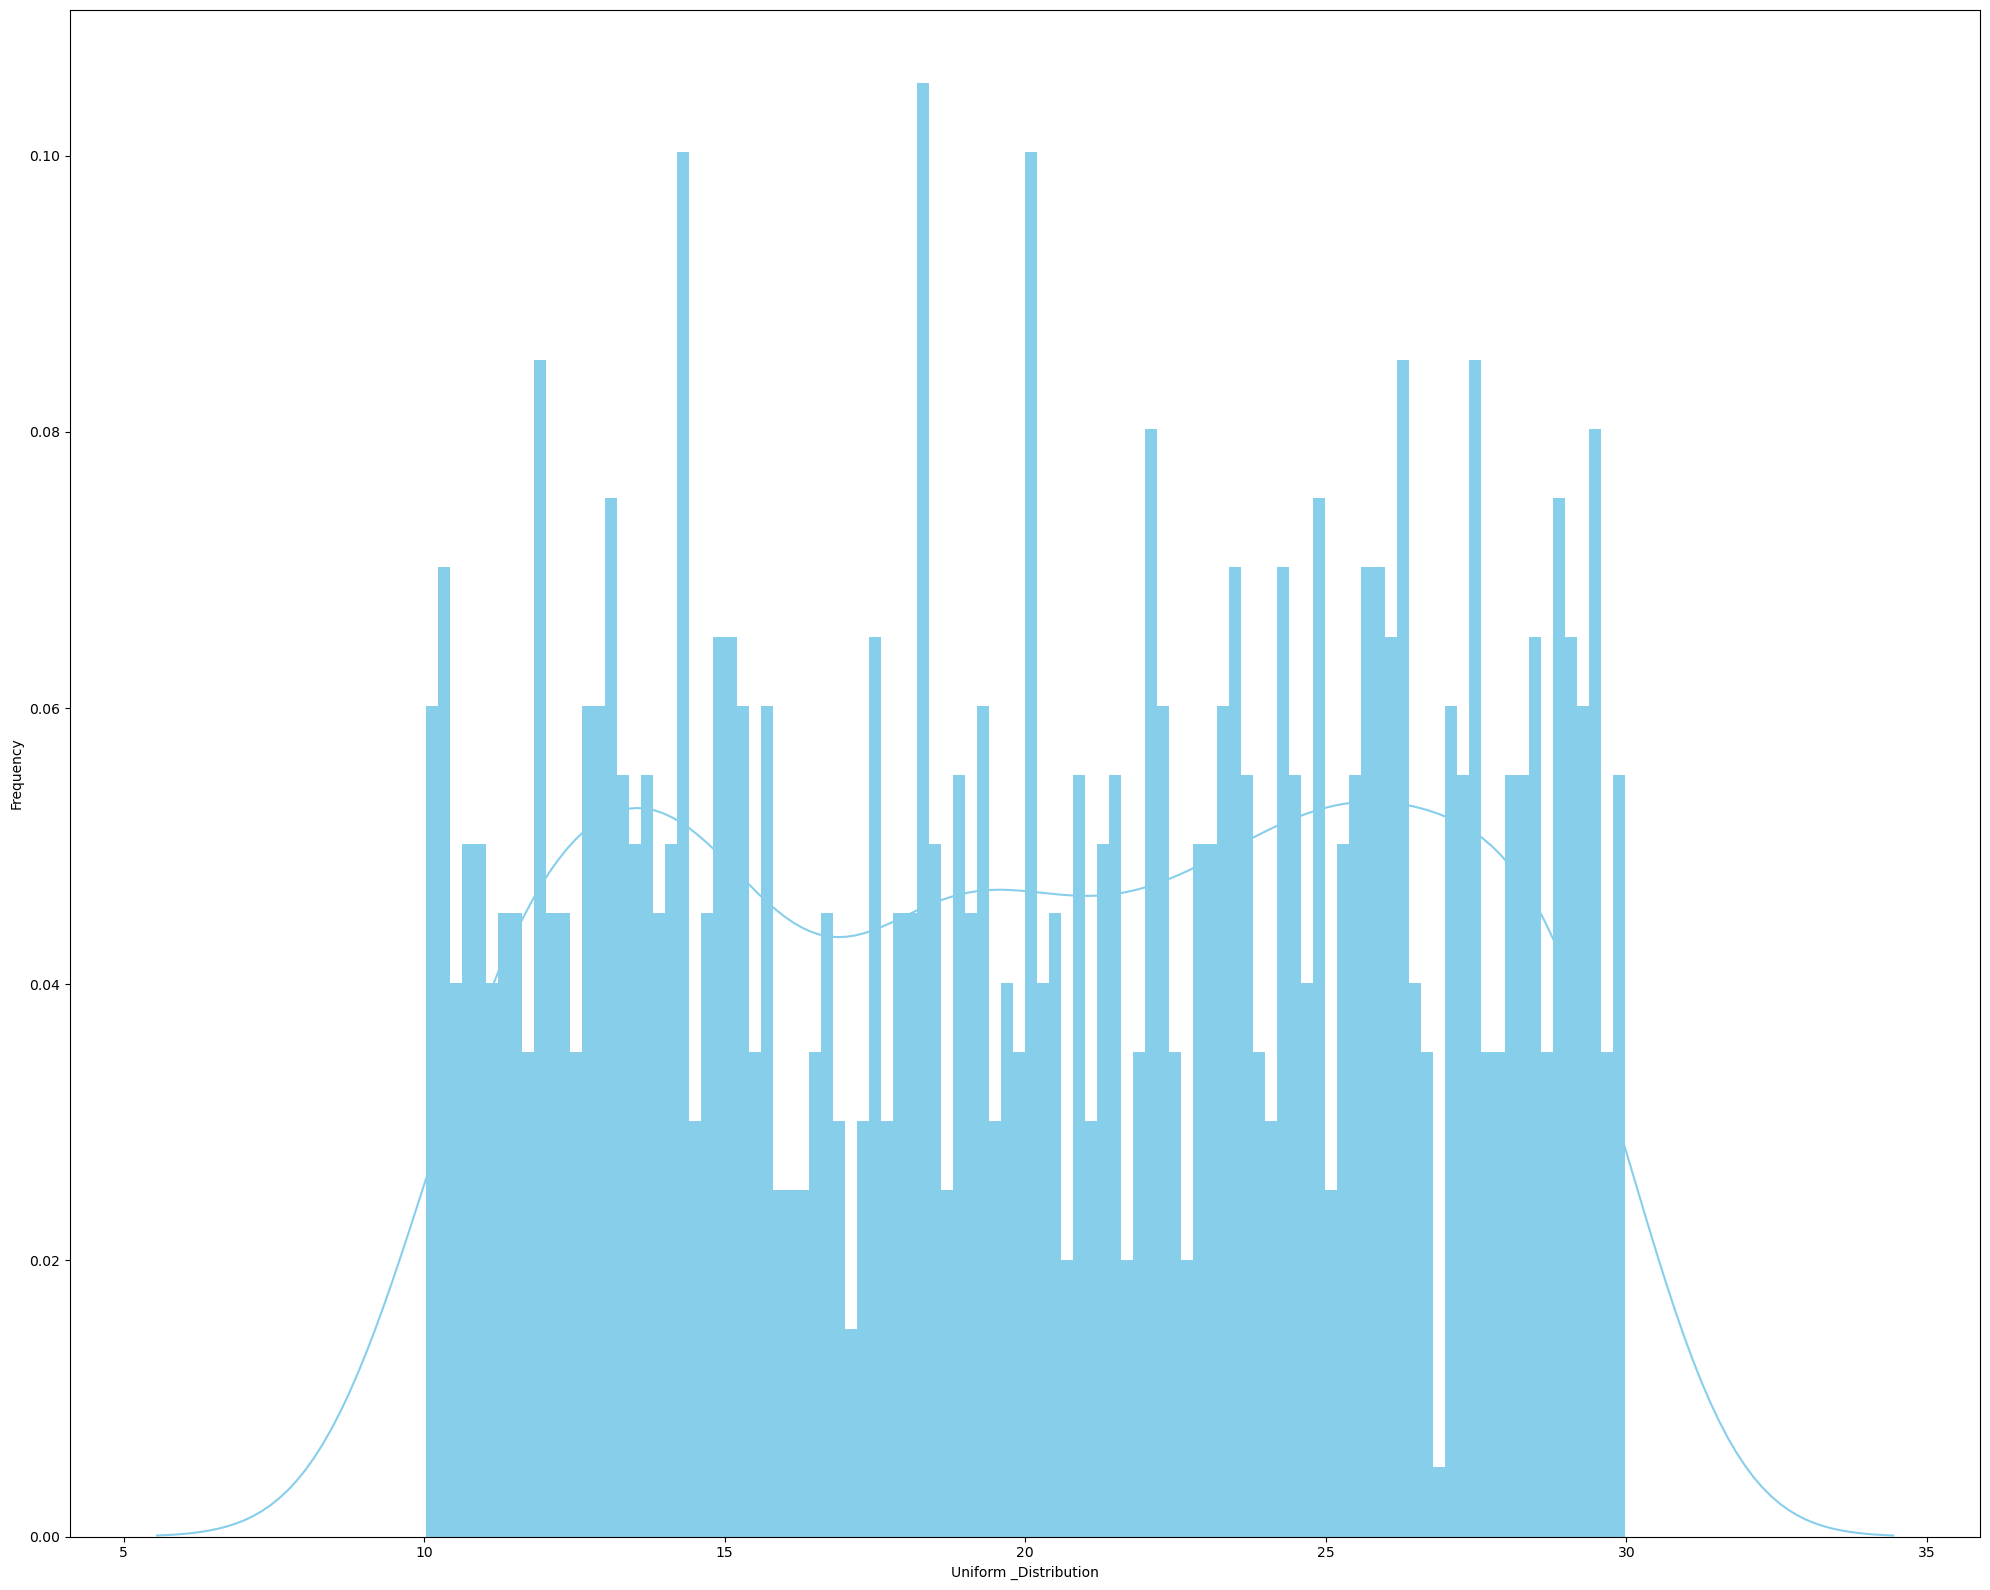

In [178]:
from scipy.stats import uniform
n=1000
start=10
width=20
data_uniform=uniform.rvs(size=n,loc=start,scale=width)
ax=sns.distplot(data_uniform, bins=100, kde=True, color= 'skyblue', hist_kws={'linewidth':15, 'alpha':1})
ax.set(xlabel='Uniform _Distribution', ylabel='Frequency')

##### There doesn't seem to be any apparent skewness in any direction, and the distribution is very consistent.

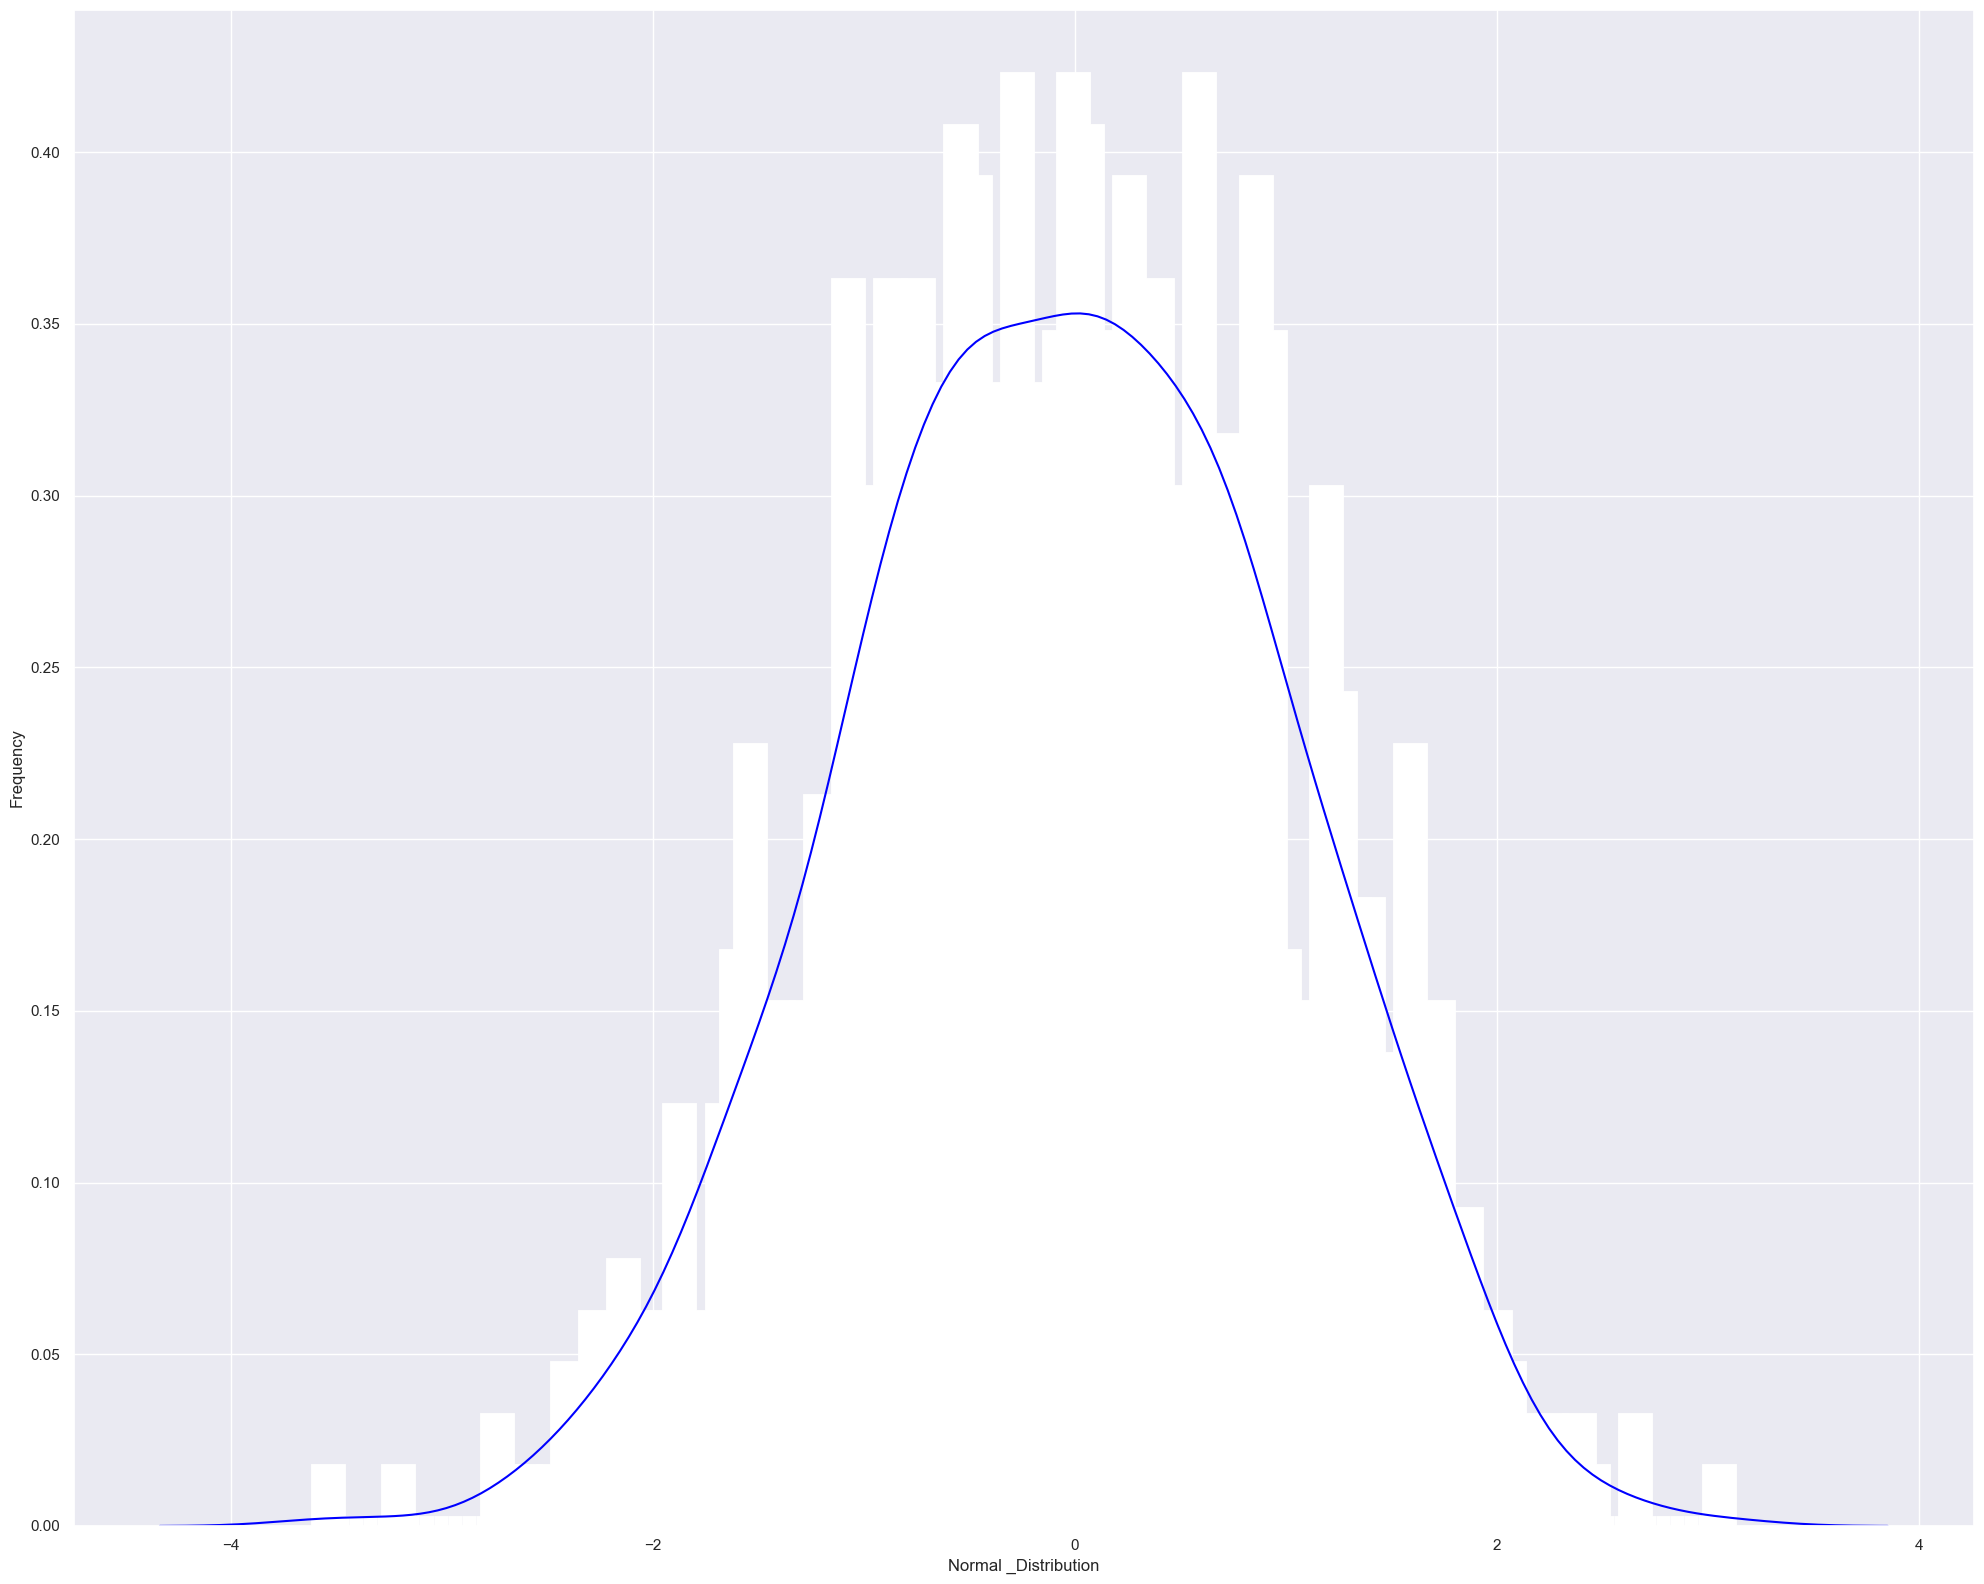

In [179]:
datapop_df_normal = pd.DataFrame(np.random.normal(size=1000))

sns.set(style="darkgrid")
ax=sns.distplot(datapop_df_normal, bins=100, kde=True, color= 'blue', hist_kws={'linewidth':15, 'alpha':1})
ax.set(xlabel='Normal _Distribution', ylabel='Frequency')
plt.show()

#### Numerical Variables Correlations

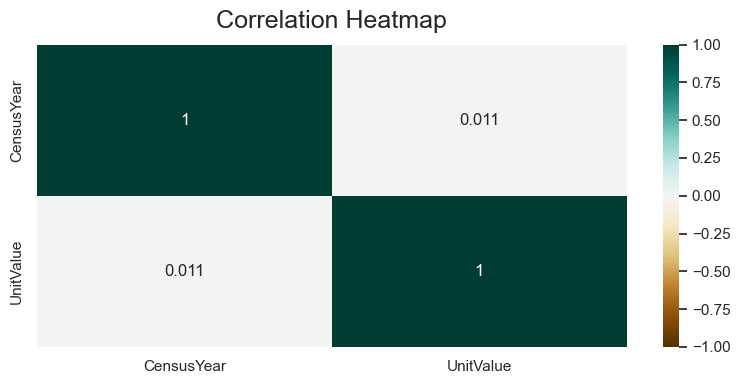

In [180]:
plt.figure(figsize=(8, 4))
heatmap = sns.heatmap(datapop_df.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12);
# save heatmap as .png file
# dpi - sets the resolution of the saved image in dots/inches
# bbox_inches - when set to 'tight' - does not allow the labels to be cropped
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')

Afeter I performed data pre-processing and checked for any missing or inconsistent values, as well as some data cleaning. Let's start with a `bar plot` to undertake an exploratory data analysis to understand the data distribution. I picked a bar plot over a box plot since it shows the variable `AgeGroup` more clearly.

For example, to visualise the distribution of 'VALUE' across various 'Age Groups'.

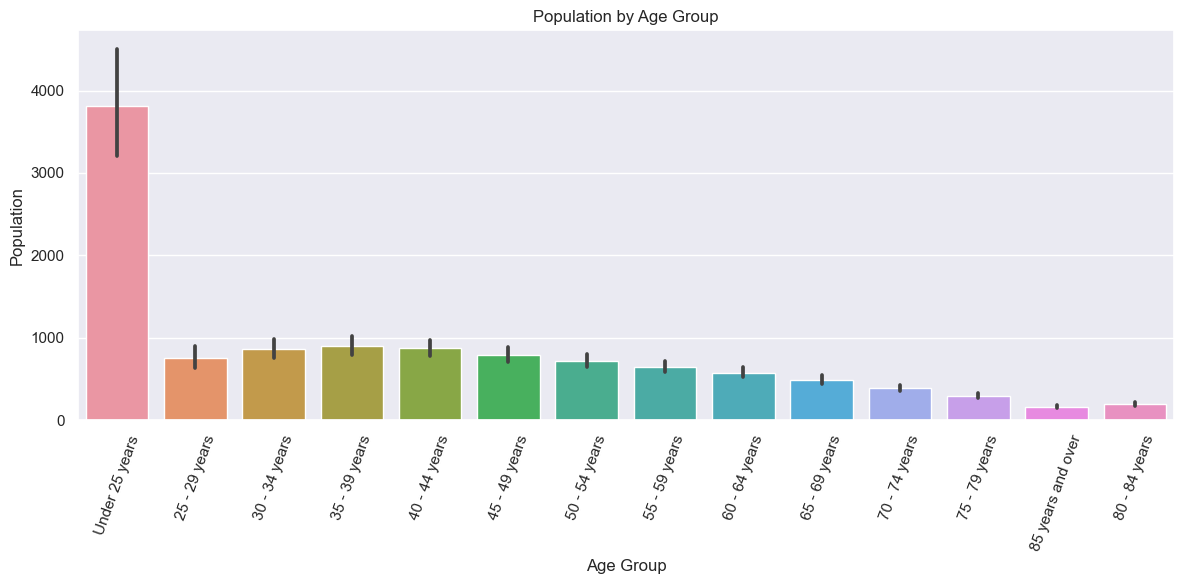

In [181]:
plt.figure(figsize=(12,6))
sns.barplot(x='AgeGroup', y='UnitValue', data=datapop_df)
plt.title('Population by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Population')
plt.xticks(rotation=70)
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x='Age Group', y='VALUE', data=datapop_df, hue='Sex')
plt.title('Population by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Population')
plt.xticks(rotation=70)
plt.show()

#### Sorting column 'Value' - ascending order. To get a better analysis of the numbers.

In [182]:
datapop_df.sort_values('UnitValue', ascending=True, inplace=True)
datapop_df.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
3363,2011,Registered Same Sex,Offaly,Female,30 - 34 years,0
33316,2022,Widowed,Sligo,Male,Under 25 years,0


#### Discrete distributions
Fitting a discrete distribution to the data, lets use libraries such as SciPy. The Poisson Distribution is a type of Probability Distribution that shows how many times an event occurs over a given time period. It is the discrete probability distribution of the number of events that occur in a given time period given the average number of occurrences of the event during that time period. 

Consider the following example of fitting a Poisson distribution.

In [183]:
from scipy import stats 
import matplotlib.pyplot as plt
from empiricaldist import Pmf , Cdf
from matplotlib.ticker import PercentFormatter

Check accuracy of cdf and ppf:

The chi-squared goodness-of-fit test is used to determine how well the Poisson distribution matches the actual data. You can fine-tune the code based on your tastes and individual data analysis needs.

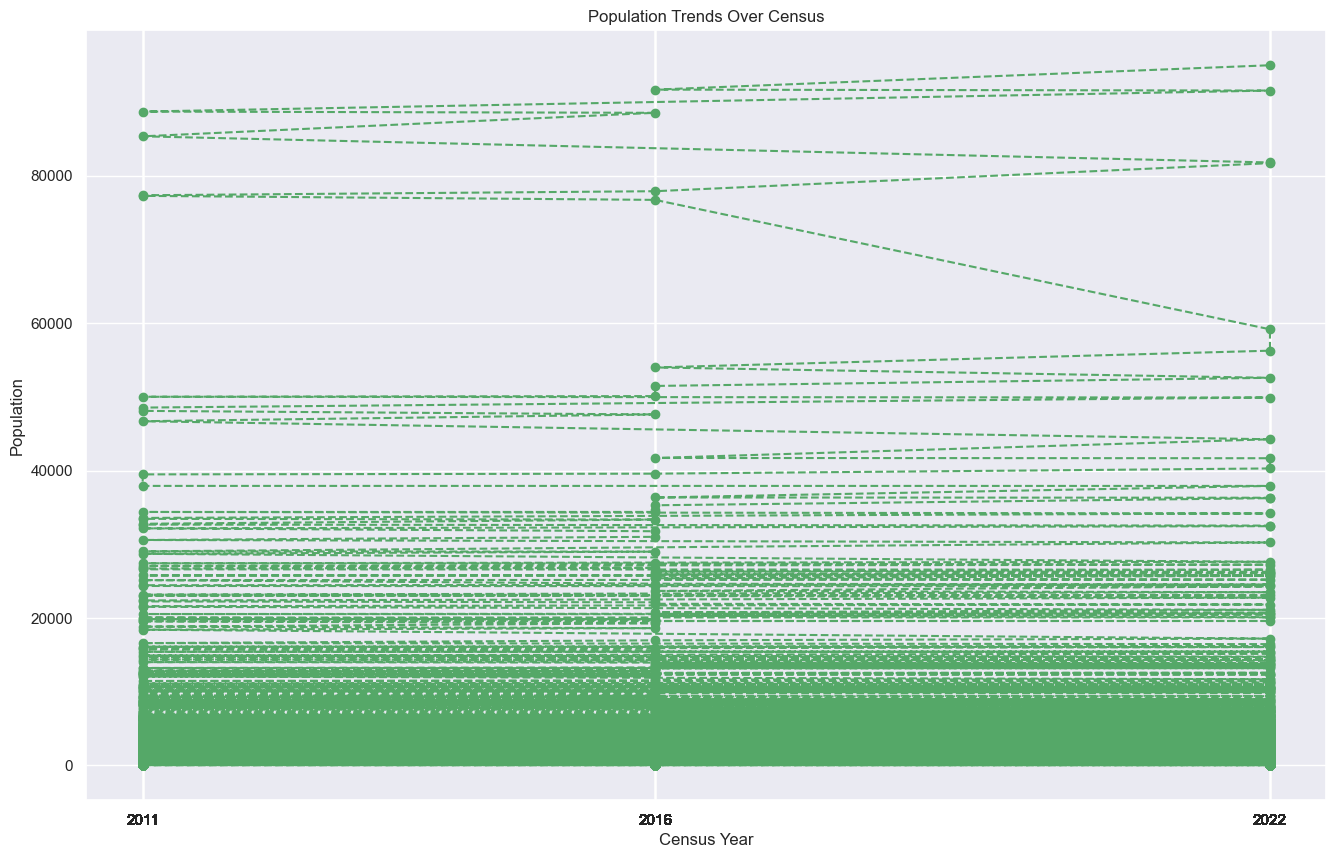

In [349]:
from scipy.stats import poisson
plt.figure(figsize=(16, 10))
plt.plot(datapop_df['CensusYear'], datapop_df['UnitValue'], marker='o', linestyle='dashed', color='g')
plt.title('Population Trends Over Census')
plt.xlabel('Census Year')
plt.ylabel('Population')
plt.xticks(datapop_df['CensusYear'])
plt.grid(True)
plt.show()

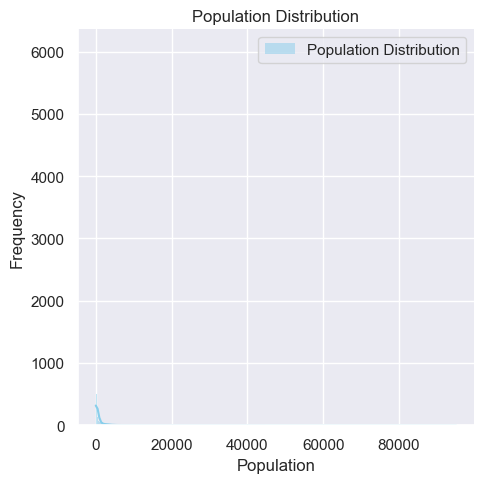

In [184]:
# Check for Poisson Distribution
sns.displot(datapop_df['UnitValue'], kde=True, color='skyblue', label='Population Distribution')
plt.title('Population Distribution')
plt.xlabel('Population')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#### Binomial Distribution

NameError: name 'r_values' is not defined

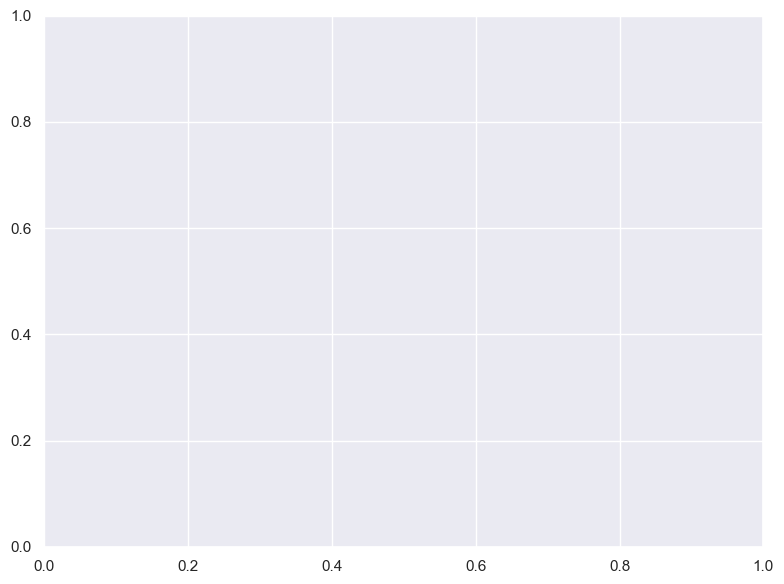

In [185]:
from scipy.stats import binom

fig, ax = plt.subplots(figsize=(8,6))
bars = plt.bar(r_values, dist, color=['skyblue', 'salmon'])


unit_value_single_female = datapop_df[(datapop_df['MaritalStatus'] == 'Single') & (datapop_df['Gender'] == 2)]['UnitValue'].sum()
n = datapop_df['UnitValue'].sum()
p_single_female = unit_value_single_female / n
r_values = [0, 1]

dist = [binom.pmf(r, 1, p_single_female) for r in r_values]
census_years = datapop_df['CensusYear']
dist = [binom.pmf(1, 1, p_single_female) for _ in census_years]

plt.bar(r_values, dist)
plt.xticks(r_values, ['Not Single Female', 'Single Female'])
plt.title('Probability of Single Female by Census')
plt.xlabel('Female Status in Census Year')
plt.ylabel('Probability')

plt.show()

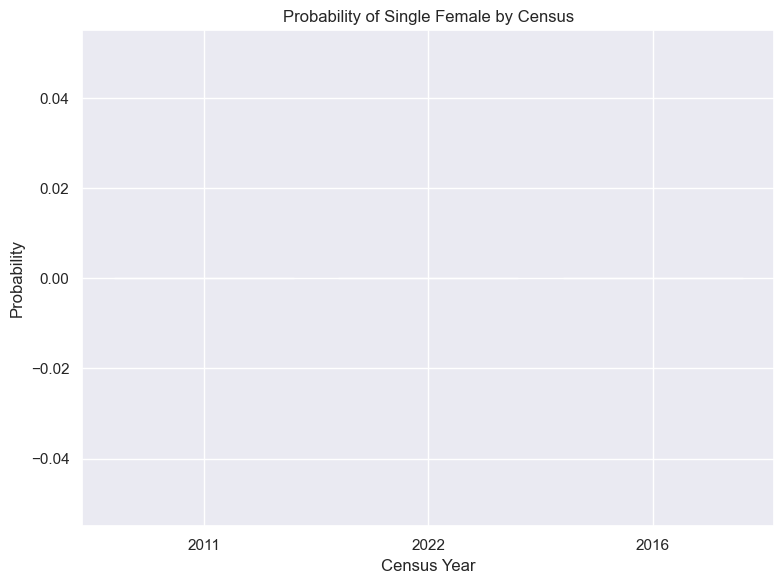

In [50]:
unit_value_single_female = datapop_df[(datapop_df['MaritalStatus'] == 'Single') & (datapop_df['Gender'] == 2)]['UnitValue'].sum()
n = datapop_df['UnitValue'].sum()
p_single_female = unit_value_single_female / n

census_years = datapop_df['CensusYear'].unique()
dist = [binom.pmf(1, 1, p_single_female) for _ in census_years]

fig, ax = plt.subplots(figsize=(8,6))
bars = plt.bar([str(year) for year in census_years], dist, color='skyblue')
plt.title('Probability of Single Female by Census')
plt.xlabel('Census Year')
plt.ylabel('Probability')
plt.show()

In [ ]:
census_years = datapop_df['CensusYear'].unique()
probs = []

for year in census_years:
    unit_value_single_female = datapop_df[(datapop_df['MaritalStatus'] == 'Single') & (datapop_df['Gender'] == 2) & (datapop_df['CensusYear'] == year)]['UnitValue'].sum()
    n = datapop_df[datapop_df['CensusYear'] == year]['UnitValue'].sum()
    p_single_female = unit_value_single_female / n
    probs.append(p_single_female)

fig, ax = plt.subplots(figsize=(8,6))
bars = plt.bar([str(year) for year in census_years], probs, color='skyblue')
plt.title('Probability of Single Female by Census')
plt.xlabel('Census Year')
plt.ylabel('Probability')

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), round(probs[i], 2), ha='center', va='bottom')

plt.show()

##### Probability of Single Female by Census

In [ ]:
from scipy.stats import binom
fig, ax = plt.subplots(figsize=(8,6))
unit_value_single_female = datapop_df[(datapop_df['MaritalStatus'] == 'Single') 
                                      & (datapop_df['Gender'] == 2)]['UnitValue'].values[0]
n = sum(datapop_df['UnitValue'])
p_single_female = unit_value_single_female / n
r_values = [0, 2]

dist = [binom.pmf(r, 1, p_single_female) for r in r_values]
plt.bar(r_values, dist)
plt.xticks(r_values, ['Not Single Female', 'Single Female'])
plt.title('Probability of Single Female by Census')
plt.xlabel('Female Status in Census Year')
plt.ylabel('Probability')
plt.show()

### Data Visualization

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.barplot(datapop_df, x='CensusYear', y='UnitValue', estimator='sum', palette='mako', errorbar=None)
ax.bar_label(ax.containers[0], fontsize=10);
plt.xticks(rotation=40)
plt.show()

####### As we can see the Ireland population of Census 2022 was 5,149,149, and it increase 8% since Census 2016.####

<Figure size 1200x600 with 0 Axes>

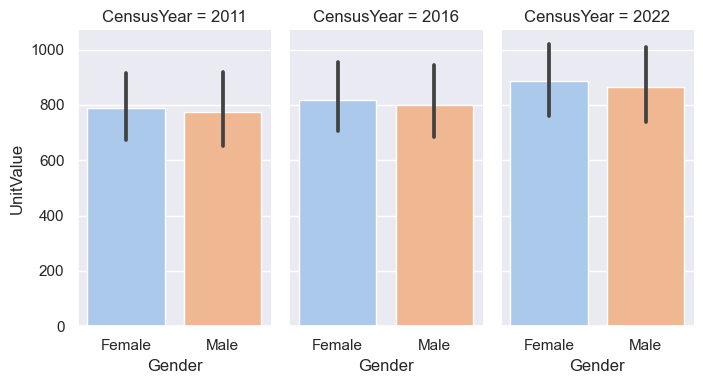

In [186]:
# Using 'catplot' to draw faceted bars, which is recommended over working directly with FacetGrid:
plt.figure(figsize=(12,6))
sns.catplot(datapop_df, kind='bar',
    x='Gender', y='UnitValue', col='CensusYear', height=4, aspect=.6, palette='pastel',)
plt.show()

In [421]:
# To obtain the precise figures for every marital status
datapop_df['MaritalStatus'].value_counts()

Registered Same Sex    2520
Widowed                2520
Divorced               2520
Remarried              2520
Separated              2520
Married                2520
Single                 2520
Name: MaritalStatus, dtype: int64

In [423]:
datapop_df[['UnitValue','MaritalStatus']].groupby('MaritalStatus').agg({'UnitValue': 'sum'})

,UnitValue
MaritalStatus,
Divorced,325085
Married,5216801
Registered Same Sex,7813
Remarried,188991
Separated,353824
Single,7809373
Widowed,597369


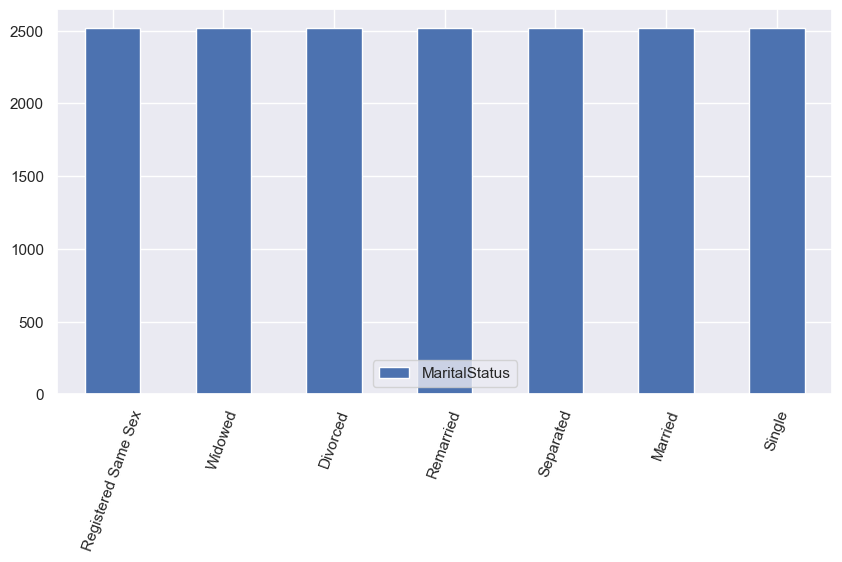

In [424]:
plt.figure(figsize=(10,5))
datapop_df['MaritalStatus'].value_counts().plot.bar()
plt.xticks(rotation=70)
plt.legend()

Let’s look at the distribution of individual features, to get some insights about the data. Plotting histograms, note that this only works for features containing numerical values.

I used the _ = func() pattern. I did in this way  to prevent displaying the func() output, which is not really helpful in this situation. The result of func() is really assigned to the variable _, sometimes known as underscore.

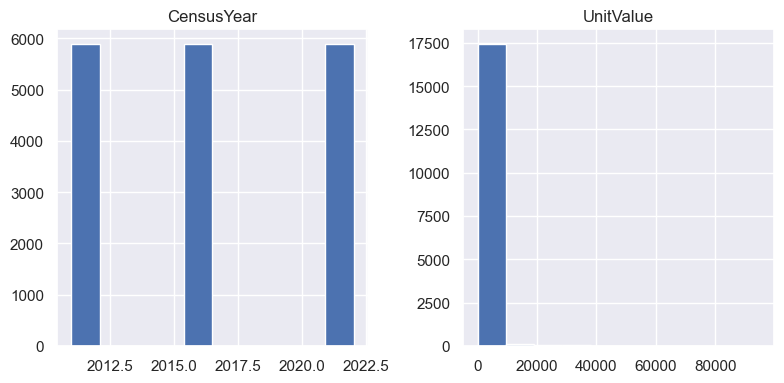

In [187]:
# to display the distribution of numeric columns
_ = datapop_df.hist(figsize=(8, 4))

Let's use scatter plots to illustrate the relationships between the variables.

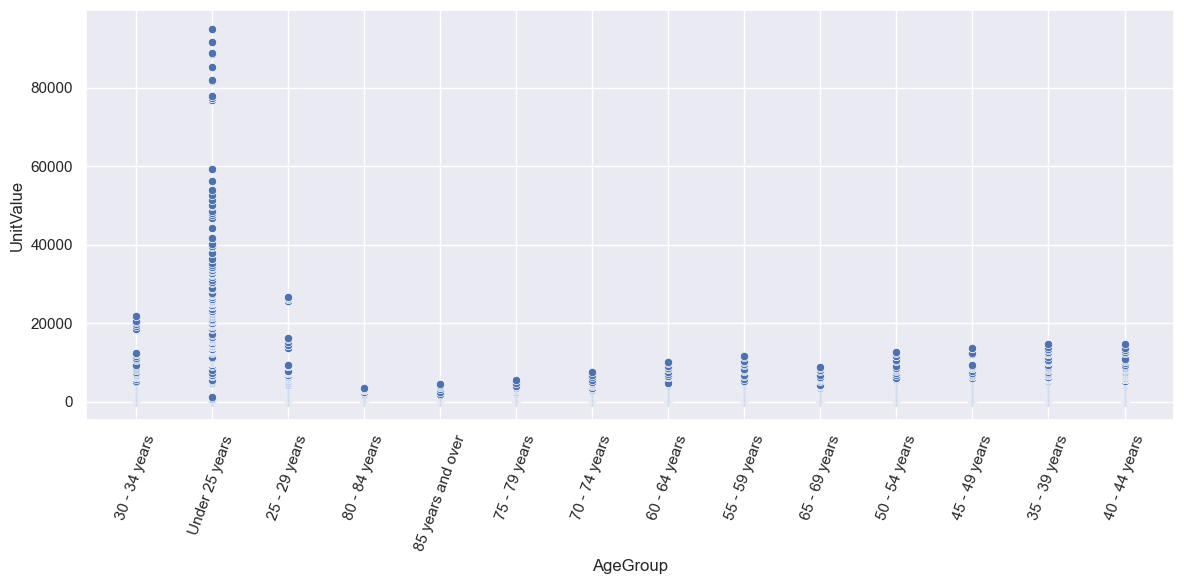

In [188]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=datapop_df, x='AgeGroup', y='UnitValue');
plt.xticks(rotation=70)
plt.show()

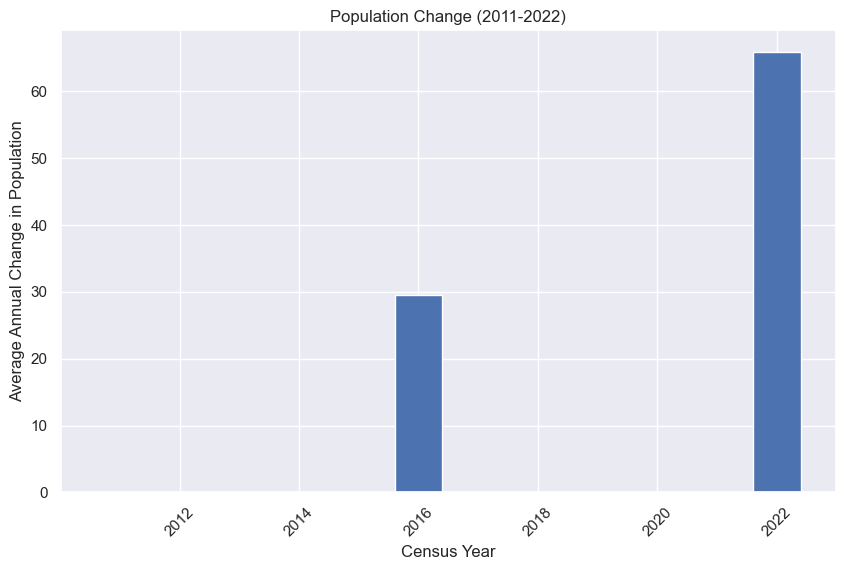

In [429]:
average_changes = datapop_df.groupby('CensusYear')['UnitValue'].sum().diff().div(datapop_df.groupby('CensusYear')['AgeGroup'].count()).fillna(0)
plt.figure(figsize=(10, 6))
plt.bar(average_changes.index, average_changes)
plt.xlabel('Census Year')
plt.ylabel('Average Annual Change in Population')
plt.title('Population Change (2011-2022)')
plt.xticks(rotation=45)
plt.show()

#### Overview of Population Change for each intercensal period (2011, 2016 & 2022)

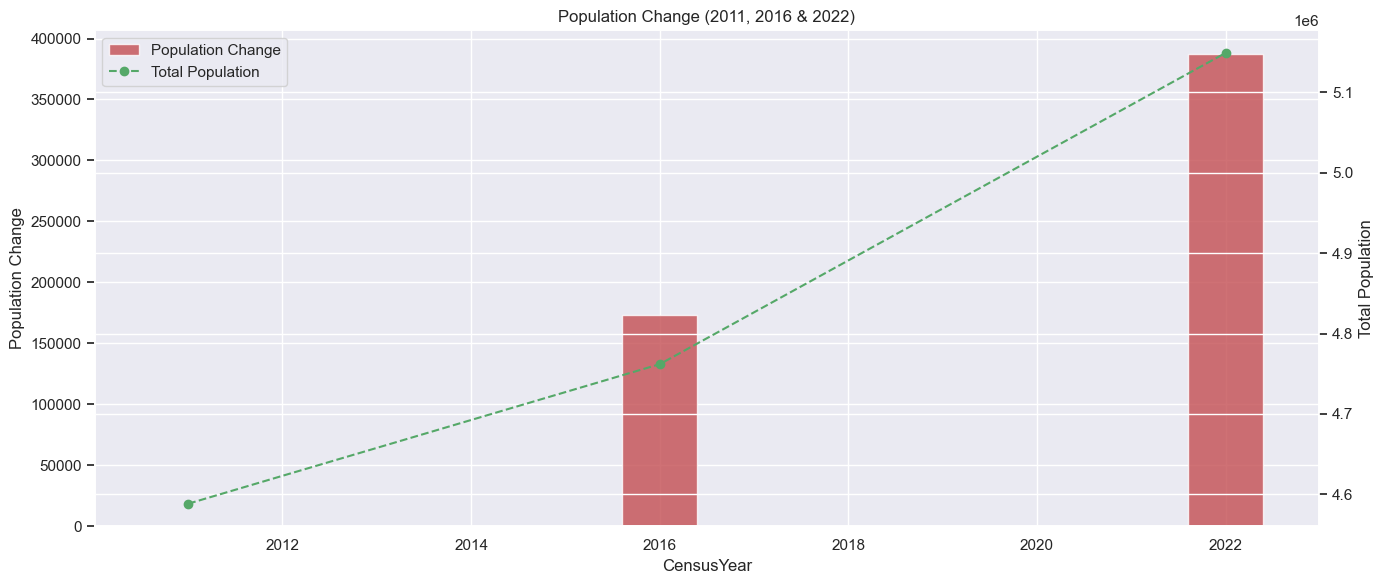

In [189]:
average_changes = datapop_df.groupby('CensusYear')['UnitValue'].sum().diff().fillna(0)
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(average_changes.index, average_changes, color='r', alpha=0.8, label='Population Change')
ax2 = ax1.twinx()
datapop_df.groupby('CensusYear')['UnitValue'].sum().plot(color='g', marker='o', ax=ax2, label='Total Population', linestyle='--')

ax1.set_xlabel('CensusYear')
ax1.set_ylabel('Population Change')
ax2.set_ylabel('Total Population')
plt.title('Population Change (2011, 2016 & 2022)')

#legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc=2)
plt.show()

In [190]:
datapop_df['CensusYear'].value_counts()

2011    5880
2022    5880
2016    5880
Name: CensusYear, dtype: int64

In [191]:
value_census = datapop_df.groupby('CensusYear')[['UnitValue']].sum() 
print(value_census.sort_values(by = ['UnitValue']))

            UnitValue
CensusYear           
2011          4588252
2016          4761865
2022          5149139


In [192]:
average_changes = datapop_df.groupby('CensusYear')['UnitValue'].sum().diff().fillna(0)
print(average_changes)


CensusYear
2011         0.0
2016    173613.0
2022    387274.0
Name: UnitValue, dtype: float64


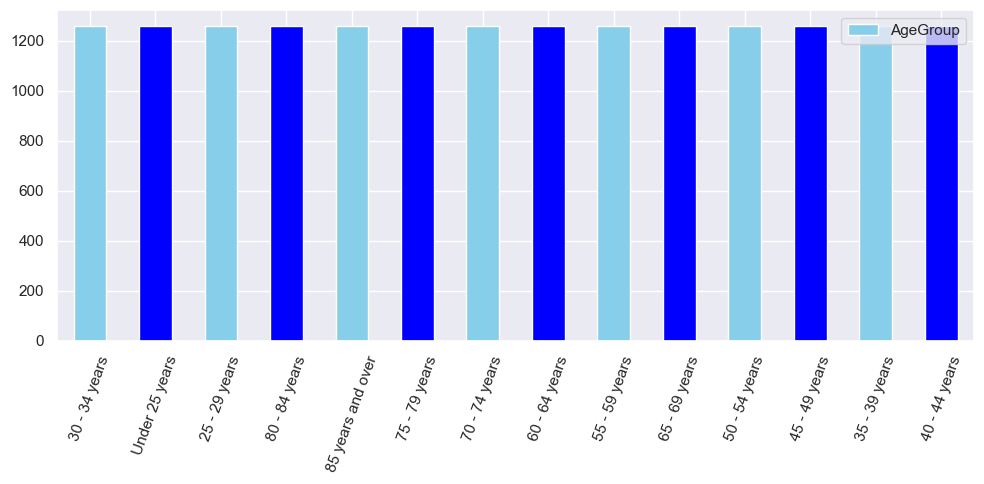

In [193]:
plt.figure(figsize=(10,5))
datapop_df['AgeGroup'].value_counts().plot.bar(color=['skyblue','blue',])
plt.xticks(rotation=70)
plt.legend()

#### Comparing historical Population by CensusYear and Gender

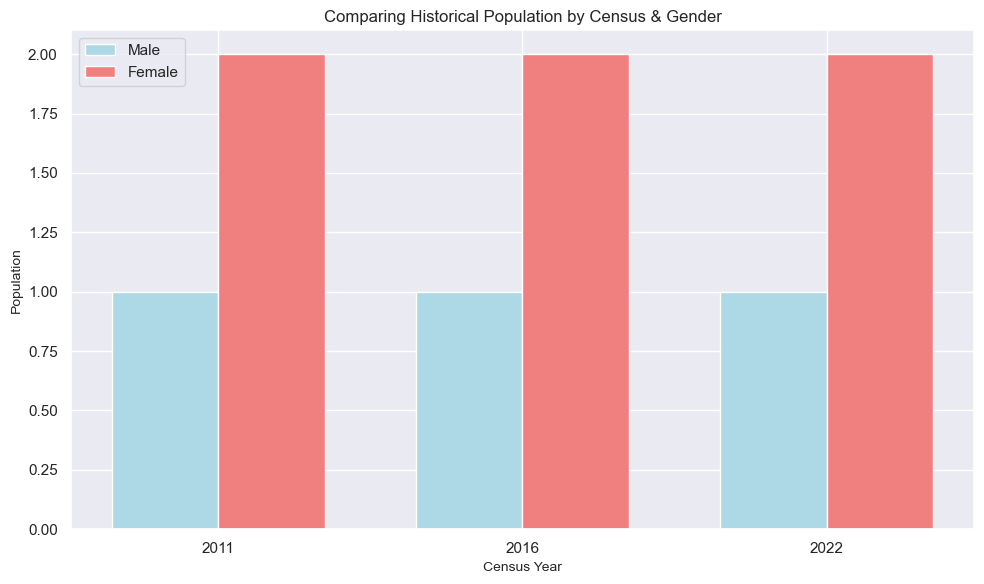

In [194]:
#Assuming 1 represents Male and 2 represents Female
CensusYear = [2011, 2016, 2022]
male_population = [1]  
female_population = [2]
ind = np.arange(len(CensusYear))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(ind - width/2, male_population, width, label='Male', color='lightblue')
rects2 = ax.bar(ind + width/2, female_population, width, label='Female', color='lightcoral')
ax.set_xlabel('Census Year', fontsize=10)
ax.set_ylabel('Population', fontsize=10)
ax.set_title('Comparing Historical Population by Census & Gender', fontsize=12)
ax.set_xticks(ind)
ax.set_xticklabels(CensusYear)
ax.legend()
plt.show()

#### Displaying two plot of Marital Status and Age Group to analianalyse the distribution of these variables. 

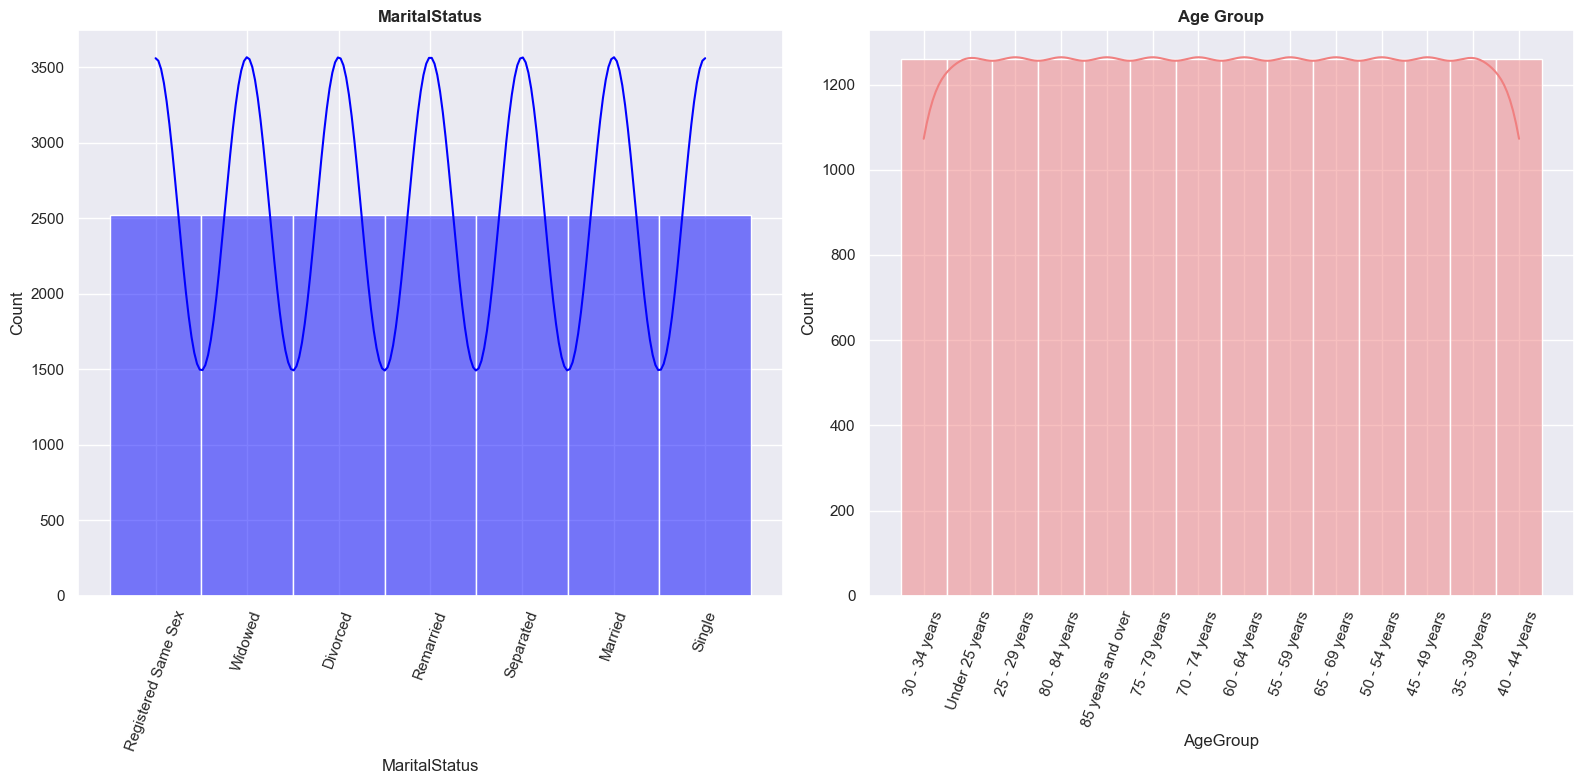

In [195]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

sns.histplot(data=datapop_df, x='MaritalStatus', kde=True, color='blue', ax=axs[0])
axs[0].set_title('MaritalStatus', fontsize=12, weight='bold')
axs[0].tick_params(axis='x', rotation=70)  

sns.histplot(data=datapop_df, x='AgeGroup', kde=True, color='lightcoral', ax=axs[1], bins=25)
axs[1].set_title('Age Group', fontsize=12, weight='bold') 
axs[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()

These variables' distributions are rather close, as you can see. Additionally, we can observe that there are "peaks and valleys for Marital Status" on the probability density kernel estimate curve for the variable.

In the first plot of Marital Status illustrates population distribution based on marital status. The histogram with the kernel density estimation (KDE) overlay depicts the frequency distribution of individuals across different marital status groups. This map aids in determining the prevalence of various marital statuses within the population. This data is useful for understanding societal dynamics and can help with focused policy planning, particularly in areas such as family welfare, healthcare, and social services.

The second plot of 'Age Group' depicts the population distribution across various age groups. KDE also displays the frequency distribution of people within specific age groupings. The 'Age Group' plot provides insights into the population's age distribution, highlighting the concentration of specific age groups and potential age-related trends. This information is useful in predicting the changing needs and demands of different age segments within the population.

#### Populations distribution by Area based on the intercensal period (2011, 2016 and 2022)

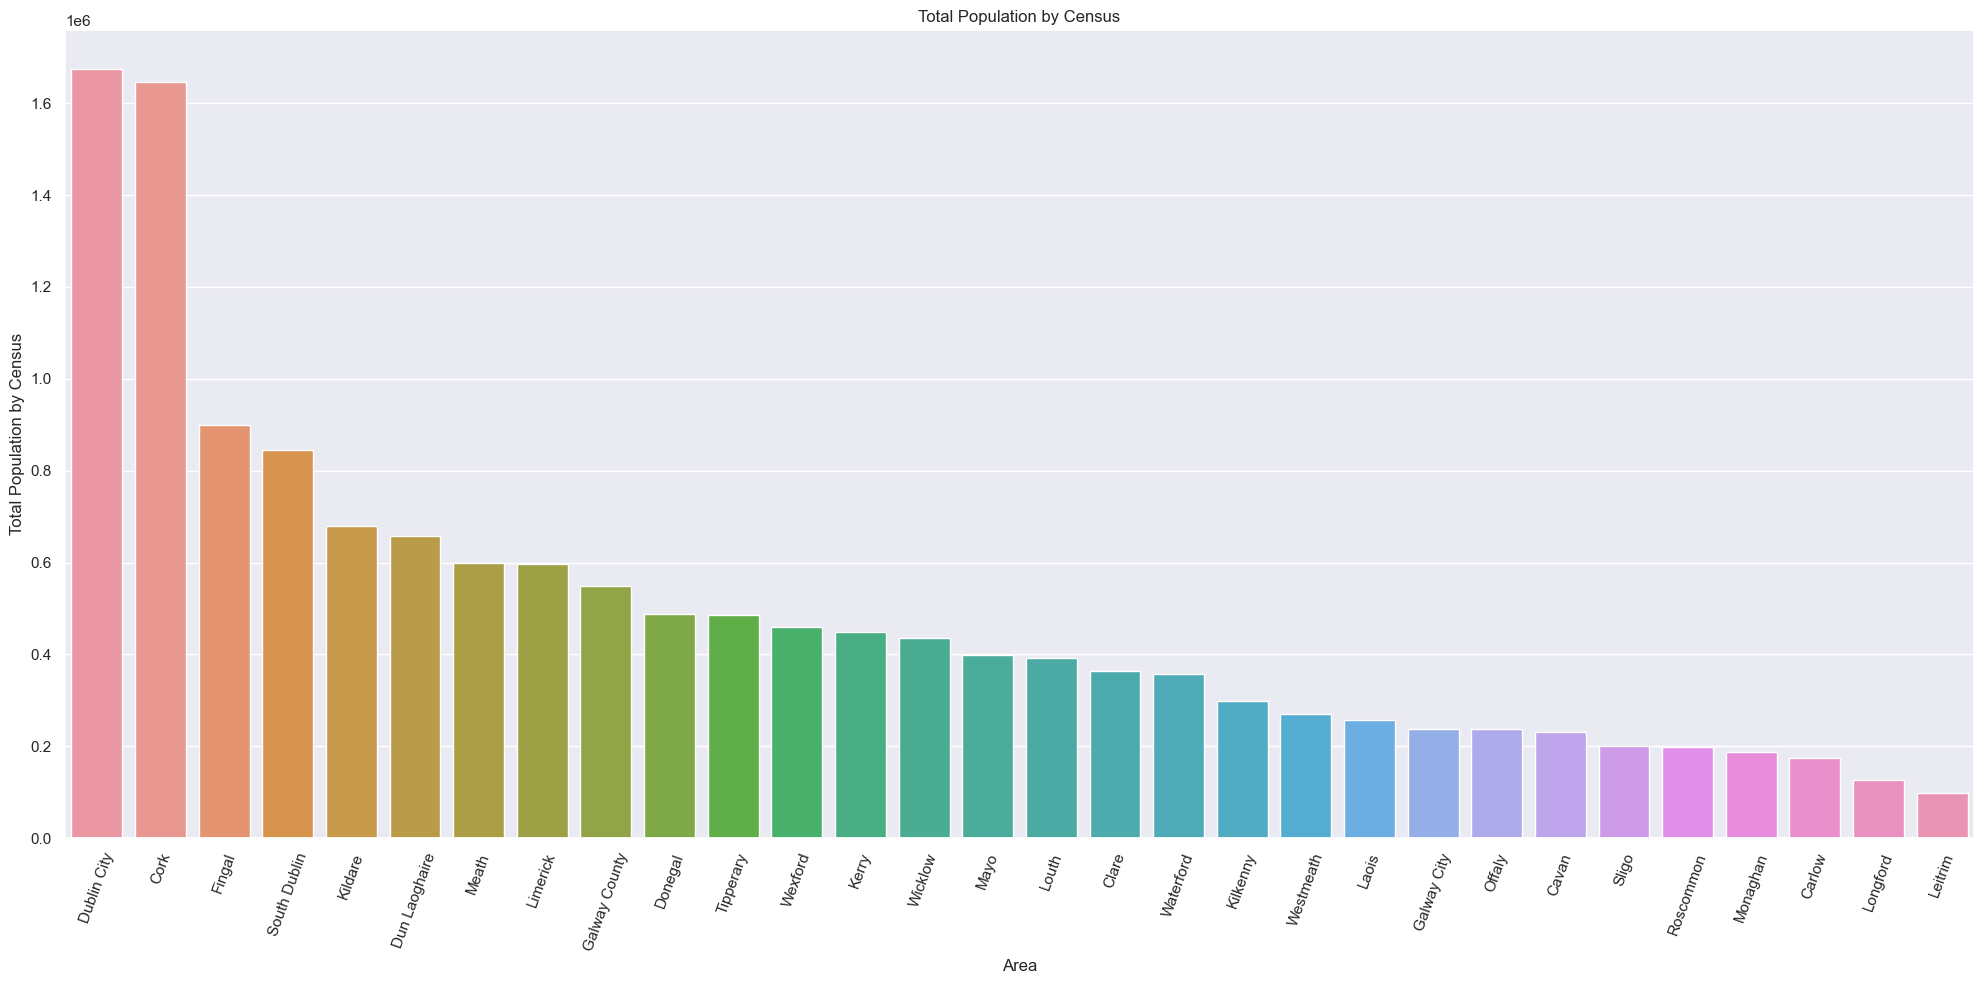

In [196]:
sorted_df = datapop_df.groupby('Area')['UnitValue'].sum().reset_index().sort_values('UnitValue', ascending=False)
sns.set(style="darkgrid")
plt.figure(figsize=(20, 10))
sns.barplot(data=sorted_df, x='Area', y='UnitValue', estimator=sum, ci=None)
plt.xticks(rotation=70)  # for better readability
plt.title('Total Population by Census')
plt.xlabel('Area')
plt.ylabel('Total Population by Census')
plt.show()

#### Population Density of 10 most densely populated Area based on the intercensal period (2011, 2016 and 2022)

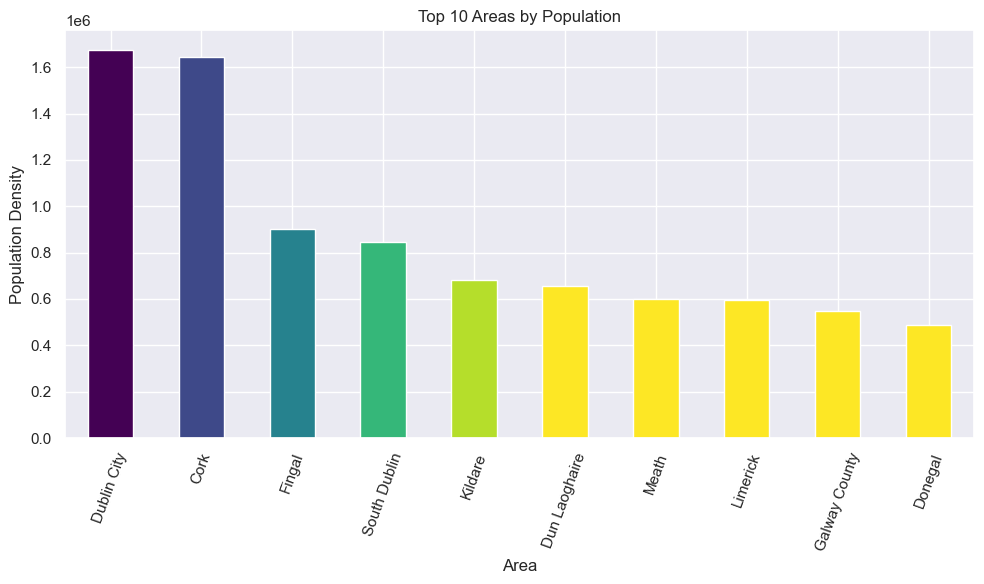

In [197]:
#Top 10 Area by Population
import matplotlib.pyplot as plt
from matplotlib import cm
top_10 = datapop_df.groupby('Area')['UnitValue'].sum().nlargest(10)
top_10.plot(kind='bar', figsize=(10, 6), color=cm.viridis(np.linspace(0, 2, len(top_10))))
plt.xticks(rotation=70)
plt.title('Top 10 Areas by Population')
plt.xlabel('Area')
plt.ylabel('Population Density')
plt.show()

The population densities of the top ten areas are clearly displayed in the bar plot. This visualisation is useful for understanding population concentrations in specific regions or cities. As we can see, Dublin (especially South Dublin, which is displayed separately) and Cork have a high concentration of Ireland's population. More research may be done to link population density to socioeconomic factors including income, education, healthcare access, and employment prospects. This can provide a thorough understanding of the social and economic dynamics of the areas of interest.

Understanding population density patterns is important for future urban planning and resource allocation when considering Future Planning. It can help policymakers make educated decisions about infrastructure development, resource distribution, and the provision of key services in densely populated areas.

In [1048]:
#WE can use .T, right after sample(5) to transpose the Feature and this method will work in cascade and sequentially.
#datapop_df.head(5).T

In [448]:
value_CensusYear = datapop_df

In [199]:
value_censusyear = datapop_df.groupby('CensusYear')[['UnitValue']].sum()
print(value_censusyear.sort_values(by = ['UnitValue']))

            UnitValue
CensusYear           
2011          4588252
2016          4761865
2022          5149139


Text(0.5, 1.0, 'Value per Year')

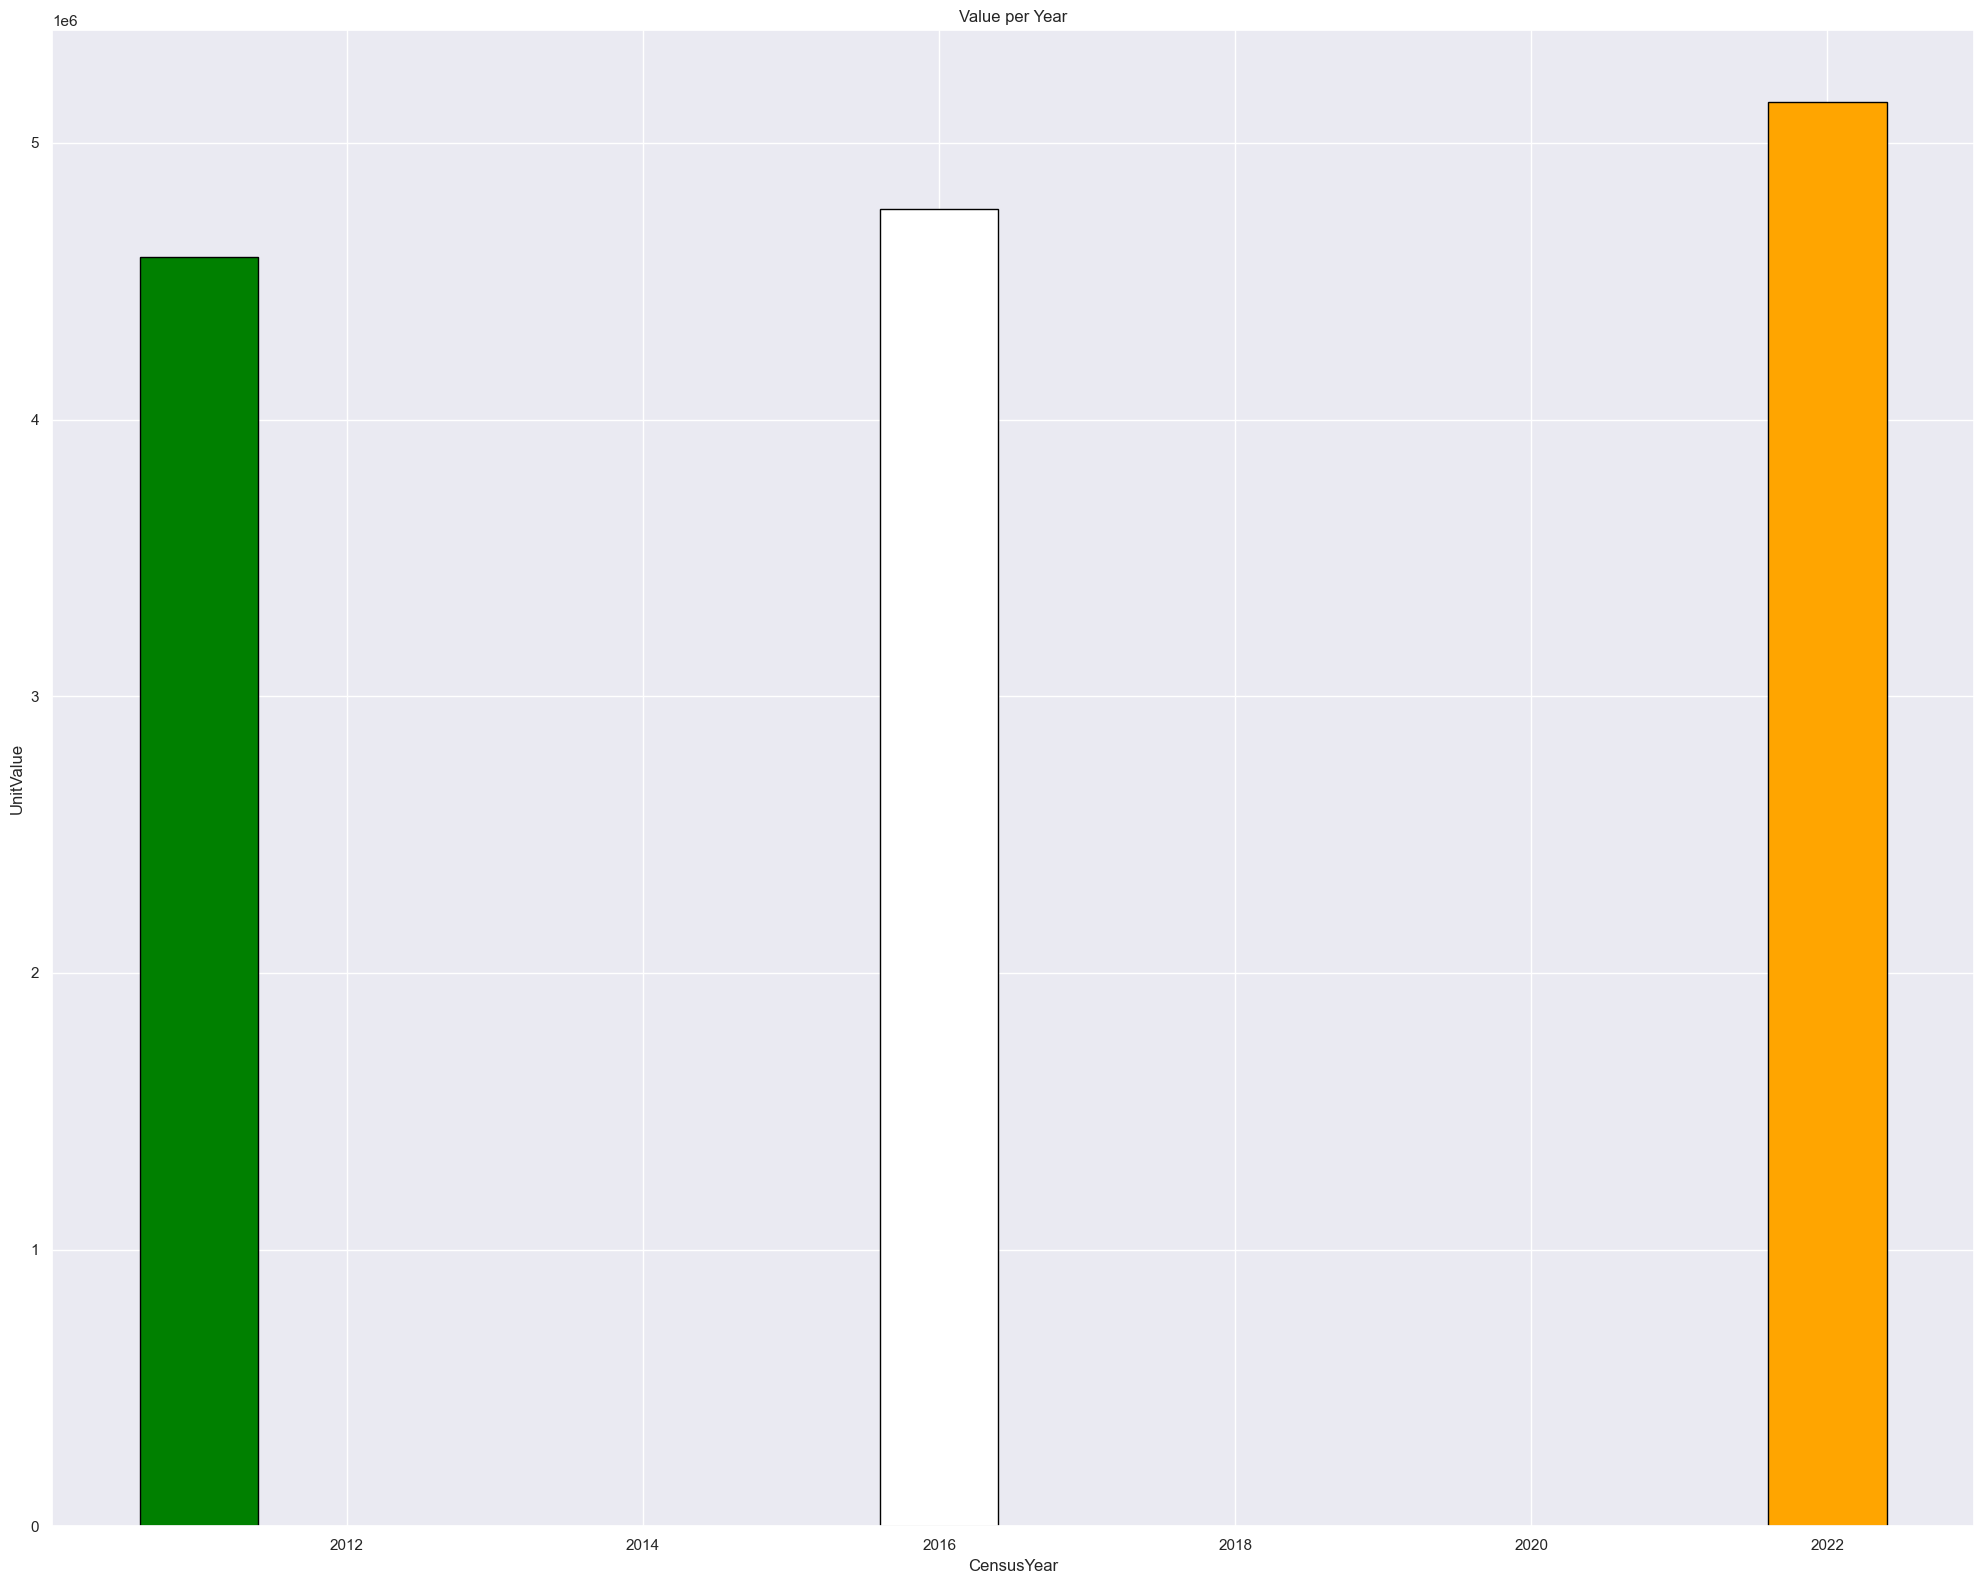

In [200]:
#to change the colors
#We need to add the labels!
colors = ['green', 'white', 'orange']
fig, ax = plt.subplots()
ax.bar(value_censusyear.index, value_censusyear['UnitValue'], color = colors, edgecolor = 'black')
plt.xlabel('CensusYear')
plt.ylabel('UnitValue')
plt.title('Value per Year')

#### Line Plot showing Population Distribution

datapop_df[['UnitValue','Area']].groupby('Area').agg({'UnitValue': 'sum'})

Using a line graph to plot the population of Ireland. I will be plotting the population Value over Time. To show it more descriptive, I added labels to the graph to make sure the data is clear for anyone who looks at it.

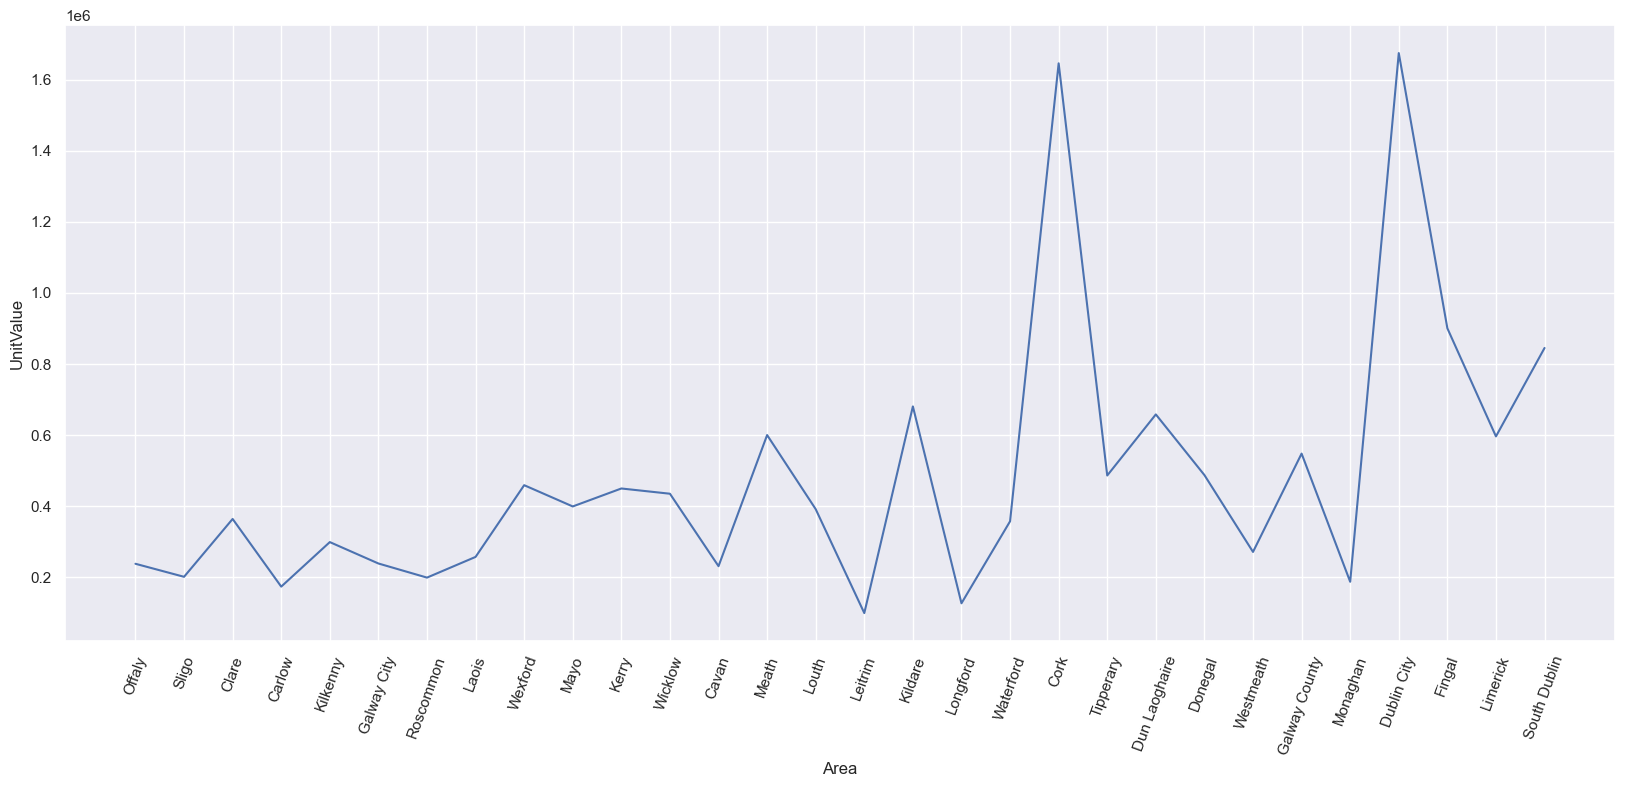

In [450]:
plt.figure(figsize=(20,8))
ax = sns.lineplot (x = 'Area', y = 'UnitValue', data = datapop_df, ci = None, estimator = sum)
plt.xticks(rotation=70)
plt.show()

To make the x-axis labels more visible, especially in this situation where they are long or numerous, I adjusted the rotation of the labels with `plt.xticks(rotation=70)` after using the parameter `plt.show()` to plot the graph without displaying the index and the text labels for each data point.

#### Feature Engineering

##### Separating Numerical and categorical variables to analysis
Since many of our features involve category variables, we are converting them into numbers using the encoded methods.

Let's to separate numerical and categorical variables to analysis.

In [201]:
cat_cols=datapop_df.select_dtypes(include=['object']).columns
num_cols = datapop_df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['MaritalStatus', 'Area', 'Gender', 'AgeGroup'], dtype='object')
Numerical Variables:
['CensusYear', 'UnitValue']


As we can see,  some of the attributes are category variables. I will handle this by encoding the variables.

### Label Encoding 

I am going to utilise Label Encoding for the categorical values 'AgeGroup' that have a natural order. The Label Encoding assigns a number value to each category.

In order to make sure that the labels are properly assigned to each category, I want to confirm the encoding mapping. Let's construct a dictionary that associates each encoded label with its associated original category in the 'AgeGroup' column. 

##### Rename the dataset

In [202]:
new_data = datapop_df

##### Changing the 'AgeGroup' variable to numeric.

In [203]:
from sklearn.preprocessing import LabelEncoder
le_encoder = LabelEncoder()

In [204]:
new_data['AgeGroup'] = le_encoder.fit_transform(new_data['AgeGroup'])
unique_sorted_values = sorted(new_data['AgeGroup'].unique())
mapping = dict(zip(unique_sorted_values, range(len(unique_sorted_values))))
print('Encoding Mapping:')

Encoding Mapping:


I can confirm the encoding is appropriately assigned for each group by printing the mapping, ensuring that "Under 25 years" is encoded as 0, "25 - 29 years" as 1, and so on. 

In [205]:
for key, value in mapping.items():
    print(f'{key} was encoded as {value}')

0 was encoded as 0
1 was encoded as 1
2 was encoded as 2
3 was encoded as 3
4 was encoded as 4
5 was encoded as 5
6 was encoded as 6
7 was encoded as 7
8 was encoded as 8
9 was encoded as 9
10 was encoded as 10
11 was encoded as 11
12 was encoded as 12
13 was encoded as 13


In [206]:
new_data.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
3363,2011,Registered Same Sex,Offaly,Female,1,0
33316,2022,Widowed,Sligo,Male,13,0


The encoded numerical values are now replaced in the 'AgeGroup' column, enabling for additional analysis and machine learning models.

#### Binary Encoding
Let's  to convert the variable gender into a binary field, that is, replace “Male” by the value 1, Female by the value 2 and Both sexes by the value 3. The 'Gender' column in the DataFrame datapop_df can be changed in-place without generating a new DataFrame by using the `inplace=True` option in the replace function. 

Using this code, I converted the values in the DataFrame's "Gender" column to numerical values derived from the dictionary dict_Gender. The overall objective is to demonstrate one method of using data dictionary and to replace the string values with their corresponding numerical equivalent.

##### Changing the 'Gender' variable to numeric.

In [207]:
from category_encoders import BinaryEncoder

In [208]:
dict_Gender = {'Male':1, 'Female': 2,}
new_data['Gender'] = new_data['Gender'].map(dict_Gender)
new_data['Gender'].replace(dict_Gender, inplace=True)
new_data.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
3363,2011,Registered Same Sex,Offaly,2,1,0
33316,2022,Widowed,Sligo,1,13,0


In [209]:
new_data.Gender.unique()

array([2, 1], dtype=int64)

In [210]:
new_data[['UnitValue','Gender']].groupby('Gender').agg({'UnitValue': 'sum'})

,UnitValue
Gender,
1,7171676
2,7327580


#### One-hot encoding

To encoding these two variables, 'MaritalStatus' 'and Area' I chose one-hot encoding because it may be more efficient when working with columns with multiple rows. When dealing with a large dataset, it is critical to process it efficiently. Then I used the category_encoders library, which provides memory-efficient methods for encoding categorical data. 

##### Changing the 'MaritalStatus' variable to numeric.

In [211]:
#pip install category_encoders

In [212]:
import category_encoders as ce
columns_to_encode = ['MaritalStatus', 'Area']
encoder = ce.OneHotEncoder(cols=columns_to_encode)
new_data = encoder.fit_transform(datapop_df)
new_data.head(2)

,CensusYear,MaritalStatus_1,MaritalStatus_2,MaritalStatus_3,MaritalStatus_4,MaritalStatus_5,MaritalStatus_6,MaritalStatus_7,Area_1,Area_2,Area_3,Area_4,Area_5,Area_6,Area_7,Area_8,Area_9,Area_10,Area_11,Area_12,Area_13,Area_14,Area_15,Area_16,Area_17,Area_18,Area_19,Area_20,Area_21,Area_22,Area_23,Area_24,Area_25,Area_26,Area_27,Area_28,Area_29,Area_30,Gender,AgeGroup,UnitValue
3363,2011,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0
33316,2022,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,13,0


In [213]:
new_data.shape

(17640, 41)

In [214]:
new_data.describe()

,CensusYear,MaritalStatus_1,MaritalStatus_2,MaritalStatus_3,MaritalStatus_4,MaritalStatus_5,MaritalStatus_6,MaritalStatus_7,Area_1,Area_2,Area_3,Area_4,Area_5,Area_6,Area_7,Area_8,Area_9,Area_10,Area_11,Area_12,Area_13,Area_14,Area_15,Area_16,Area_17,Area_18,Area_19,Area_20,Area_21,Area_22,Area_23,Area_24,Area_25,Area_26,Area_27,Area_28,Area_29,Area_30,Gender,AgeGroup,UnitValue
count,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000
mean,2016.333333,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,1.500000,6.500000,821.953288
std,4.497040,0.349937,0.349937,0.349937,0.349937,0.349937,0.349937,0.349937,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.500014,4.031243,3561.861167
min,2011.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2011.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,10.000000
50%,2016.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,6.500000,97.000000
75%,2022.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000,389.000000
max,2022.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,13.000000,95005.000000


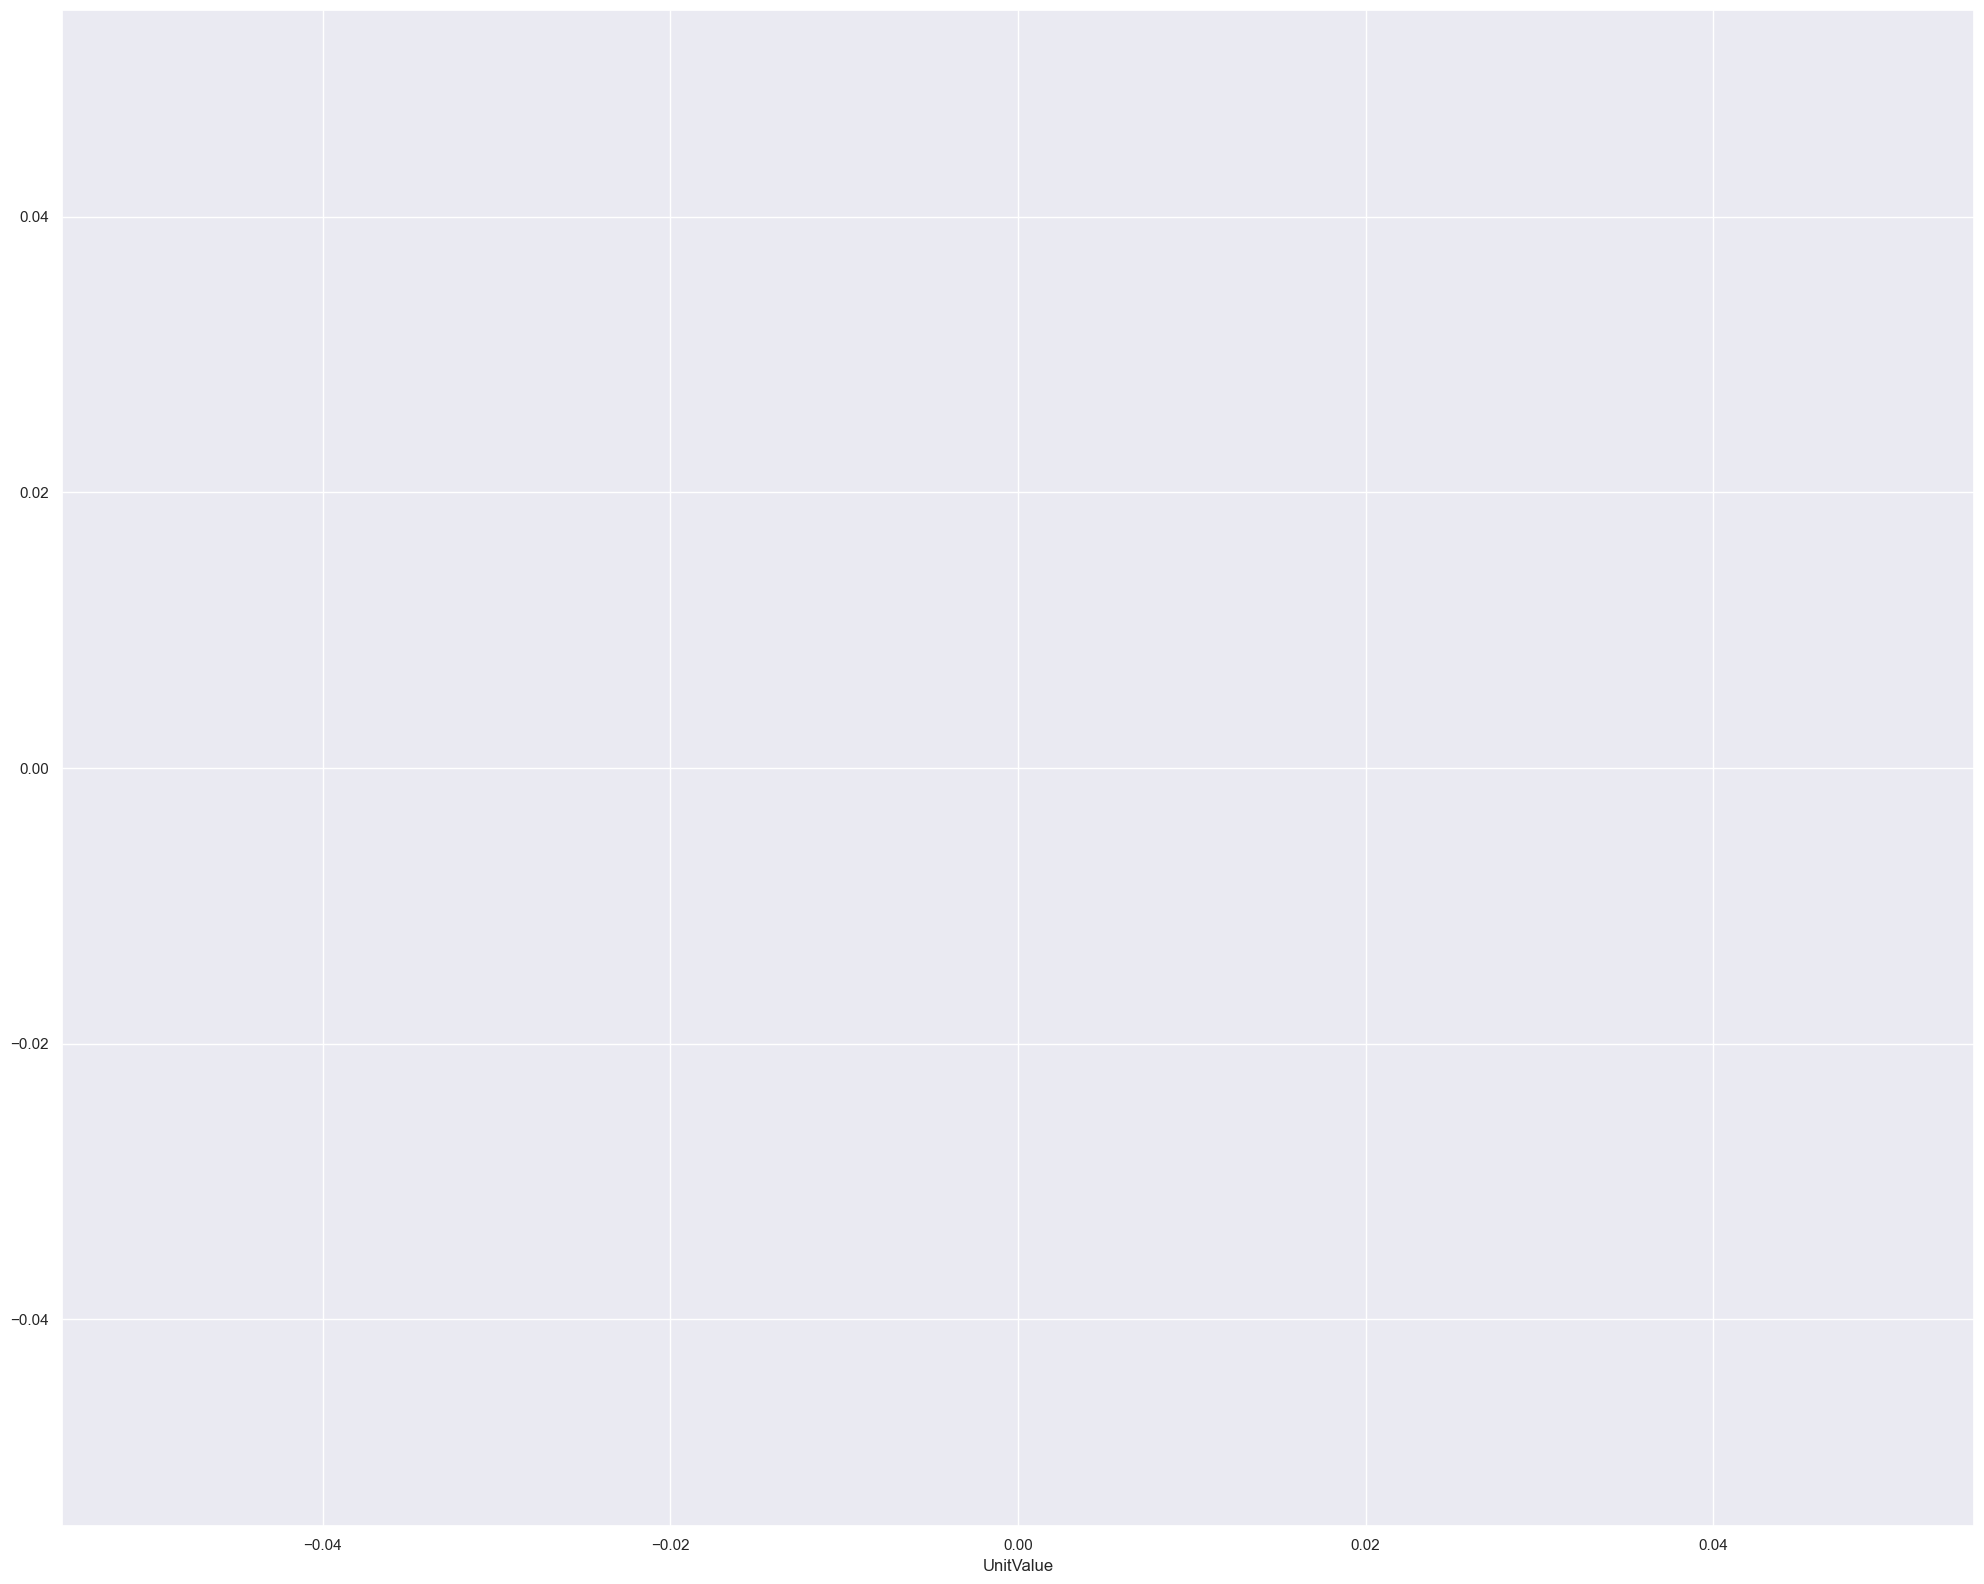

In [215]:
sns.kdeplot(new_data.UnitValue[new_data.Gender=='1'], label='Male', shade=True)
sns.kdeplot(new_data.UnitValue[new_data.Gender=='2'], label='Female', shade=True)
plt.xlabel('UnitValue');
plt.show()

##### Gender disparities: Look into how the population is divided into genders. Is there a statistically significant difference in population numbers or trends between men and women? Look for patterns or changes in gender over time.

#### Gender distribution

In [216]:
gender_counts = new_data['Gender'].value_counts()

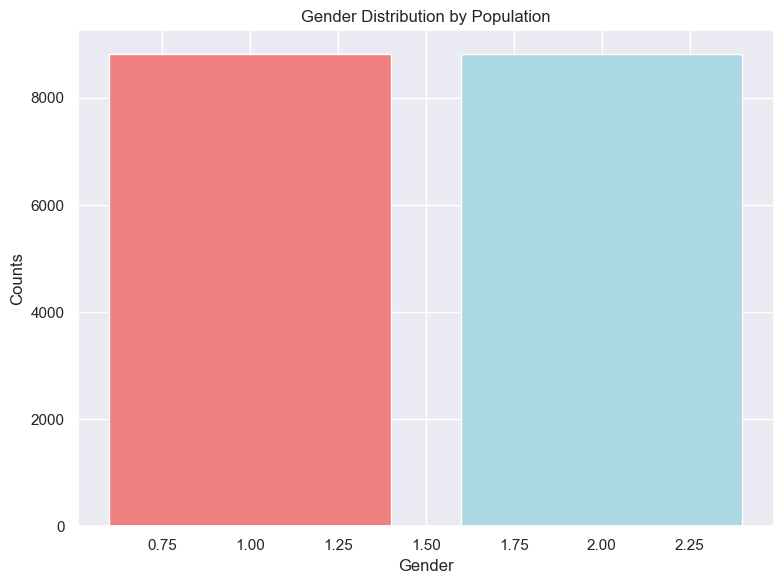

In [217]:
plt.figure(figsize=(8, 6))
plt.bar(gender_counts.index, gender_counts.values, color=['lightblue', 'lightcoral'])
plt.title('Gender Distribution by Population')
plt.xlabel('Gender')
plt.ylabel('Counts')
plt.show()

#### Using a line plot, display the gender-specific population trends over several Census Years.

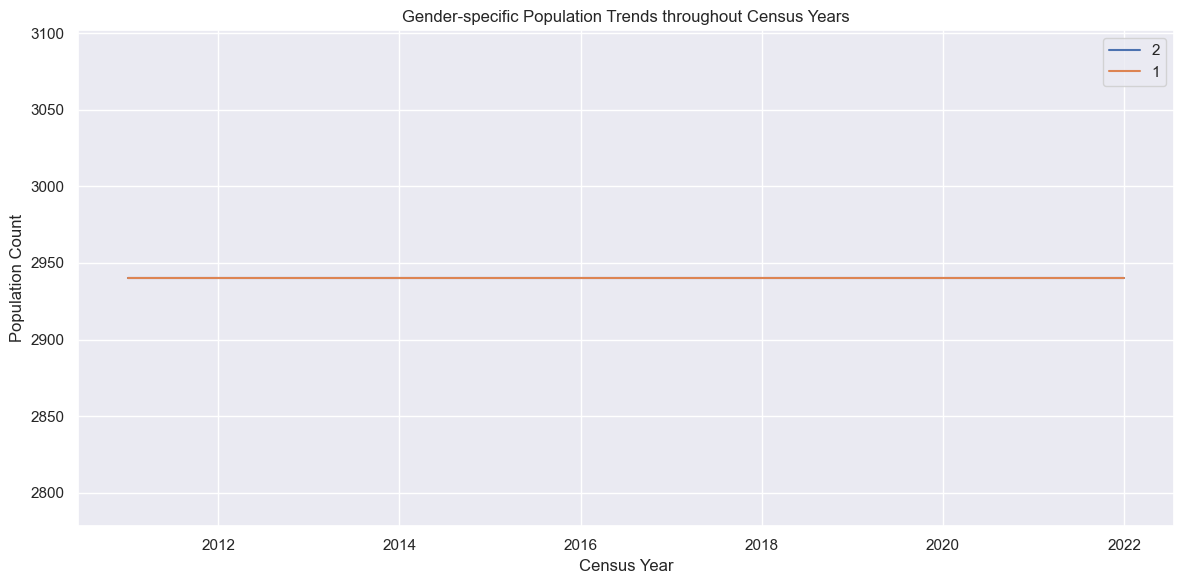

In [218]:
plt.figure(figsize=(12, 6))
for gender in new_data['Gender'].unique():
    plt.plot(new_data[new_data['Gender'] == gender].groupby('CensusYear').size(), label=gender)
plt.title('Gender-specific Population Trends throughout Census Years')
plt.xlabel('Census Year')
plt.ylabel('Population Count')
plt.legend()
plt.show()

In [765]:
print(new_data['Gender'].dtype)  
print(new_data['Gender'].value_counts())

int64
1    8820
2    8820
Name: Gender, dtype: int64


sns.kdeplot(datapop_df.UnitValue[datapop_df.Gender=='1'], label='Male', shade=True)
sns.kdeplot(datapop_df.UnitValue[datapop_df.Gender=='2'], label='Female', shade=True)
plt.xlabel('UnitValue');
plt.show()

#### Scaling numerical features 

In [219]:
correlation_heatmap(new_data, 30,15)

NameError: name 'correlation_heatmap' is not defined

#I need to plot the Population by single year of age group and gender,  based on census year 2011, 2016 2022
### For example, assuming you have data for male and female populations for the census years 2011, 2016, and 2022:
census_years = [2011, 2016, 2022]  # Define the census years
male_population_2011 = [...]  # Populate with the actual data for male population in 2011
female_population_2011 = [...]  # Populate with the actual data for female population in 2011
male_population_2016 = [...]  # Populate with the actual data for male population in 2016
female_population_2016 = [...]  # Populate with the actual data for female population in 2016
male_population_2022 = [...]  # Populate with the actual data for male population in 2022
female_population_2022 = [...]  # Populate with the actual data for female population in 2022

### Plotting the data
plt.figure(figsize=(12, 6))
plt.plot(census_years, male_population_2011, marker='o', label='Male Population 2011')
plt.plot(census_years, female_population_2011, marker='o', label='Female Population 2011')
plt.plot(census_years, male_population_2016, marker='o', label='Male Population 2016')
plt.plot(census_years, female_population_2016, marker='o', label='Female Population 2016')
plt.plot(census_years, male_population_2022, marker='o', label='Male Population 2022')
plt.plot(census_years, female_population_2022, marker='o', label='Female Population 2022')
plt.xlabel('Census Year')
plt.ylabel('Population')
plt.title('Population by Single Year of Age and Sex (Census 2011, 2016, 2022)')
plt.legend()
plt.grid(True)
plt.show()


#Changing the 'Customer_type' variable to numeric.
dict_Customer_type = {'Normal':0, 'Member': 1,}
data_smkt['Customer_type'] = data_smkt['Customer_type'] = data_smkt['Customer_type'].map(dict_Customer_type)

#Changing the 'Payment' variable to numeric.
dict_Payment = {'Cash':1, 'Credit card': 2,'Ewallet': 3}
data_smkt['Payment'] = data_smkt['Payment'] = data_smkt['Payment'].map(dict_Payment)

# References:
https://data.cso.ie/

https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.background_gradient.html

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

https://matplotlib.org/stable/plot_types/index.html

https://matplotlib.org/stable/users/explain/colors/colormaps.html

https://www.khanacademy.org/math/cc-sixth-grade-math/cc-6th-data-statistics/cc-6th-box-whisker-plots/v/interpreting-box-plots

https://www.oreilly.com/library/view/python-data-science/9781491912126/ch04.html

https://towardsdatascience.com/matplotlib-making-data-visualization-interesting-8bac1eb3d25c

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

https://www.sciencedirect.com/topics/social-sciences/kurtosis

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transpose.html

Image:
https://www.datascience-pm.com/crisp-dm-2/